# FIFA 20 Player Segmentation & Performance Analysis

## Name
Joel Richard. I

## Project Type
Unsupervised Machine Learning (Clustering) + Exploratory Data Analysis

## Contribution
Individual


# **Project Summary -**

>This project presents a comprehensive analysis and segmentation of FIFA 20 players using **unsupervised machine learning techniques**. The primary objective was to identify meaningful player groups based on performance attributes and uncover hidden patterns within high-dimensional football data. By leveraging **data analytics**, **feature engineering**, and **clustering algorithms**, the project transforms raw player statistics into actionable strategic insights.

>The analysis began with an in-depth **Exploratory Data Analysis (EDA)** phase. Key distributions such as **overall rating**, **potential**, **market value**, and core skill attributes were examined to understand player performance patterns. Correlation analysis revealed strong relationships between performance indicators such as **pace, shooting, dribbling, and overall rating**, confirming their influence on player valuation. This step provided critical business context and validated the relevance of selected features.

>During the **data preprocessing** stage, several essential transformations were performed. Missing values were handled systematically to ensure dataset integrity. Financial columns such as market value and wage were converted into numerical format to enable quantitative analysis. To ensure fairness in distance-based clustering, **feature scaling using StandardScaler** was applied. This prevented attributes with larger numerical ranges from dominating the clustering process.

>The core modeling phase implemented the **K-Means Clustering algorithm**, a distance-based segmentation technique. The optimal number of clusters was determined using the **Elbow Method** and validated with the **Silhouette Score**, ensuring robust and meaningful segmentation. Players were grouped into distinct clusters that represented performance-based categories such as **elite performers**, **balanced players**, **defensive specialists**, and **high-potential emerging talents**.

>To improve interpretability and visualization, **Principal Component Analysis (PCA)** was applied for **dimensionality reduction**. PCA transformed complex multi-feature data into three principal components, enabling clear visualization of cluster separation in 2D and 3D space. These visualizations confirmed strong structural grouping and improved model interpretability for non-technical stakeholders.

>From a business perspective, this segmentation framework provides valuable insights for **football scouting**, **transfer market evaluation**, and **squad optimization**. Clubs can identify undervalued talents, detect performance gaps, and make informed recruitment decisions based on data-driven evidence. Integrating performance metrics with financial indicators enhances strategic planning and risk mitigation in player investments.

>The project demonstrates strong **model robustness**, supported by validation metrics and consistent cluster patterns. It highlights the practical application of **unsupervised learning**, **data-driven decision making**, and **sports analytics** in modern football management.

>Overall, this study successfully showcases how machine learning can convert complex sports performance data into strategic intelligence, bridging the gap between analytics and real-world football operations.


# **GitHub Link** 

https://github.com/Richard-26/Heart-Disease-Prediction-ml.git

# **Problem Statement**

>In modern football, player evaluation and recruitment decisions increasingly rely on **data-driven analysis** rather than subjective judgment alone. With thousands of players available across leagues worldwide, identifying meaningful patterns within large performance datasets has become both essential and challenging.

>The FIFA 20 dataset contains extensive player attributes, including **overall rating, potential, pace, shooting, passing, dribbling, defending, physical strength, market value, and wage information**. However, this high-dimensional data makes it difficult to manually segment players into meaningful categories for strategic decision-making.

The core problem addressed in this project is:

>How can we use **unsupervised machine learning techniques** to segment football players into distinct performance-based groups using their statistical attributes?

>Specifically, the objective is to apply **clustering algorithms** to identify natural groupings among players without predefined labels. These clusters should represent meaningful categories such as elite performers, defensive specialists, balanced players, and high-potential talents.

Additionally, the project aims to:

>Reduce high-dimensional performance data using **dimensionality reduction techniques**.

>Validate cluster quality using appropriate **evaluation metrics**.

>Translate analytical results into actionable **business insights** for scouting and recruitment strategies.

>By solving this problem, football clubs and analysts can leverage **machine learning-based segmentation** to improve talent identification, optimize squad composition, and make financially informed transfer decisions.

>Ultimately, the goal is to transform raw performance statistics into structured, interpretable, and strategically valuable intelligence through advanced data analytics.


# **General Guidelines** : -

>Follow a structured **Data Science workflow** from data understanding to model evaluation.

>Ensure proper **data cleaning and preprocessing** before applying any machine learning techniques.

>Handle **missing values and outliers** appropriately to maintain data integrity.

>Perform careful **feature selection and scaling**, especially for distance-based algorithms.

>Use suitable **clustering evaluation methods** such as the Elbow Method and Silhouette Score.

>Apply **dimensionality reduction (PCA)** for better visualization and interpretability.

>Maintain clean, well-documented, and reproducible code.

>Translate analytical findings into meaningful **business insights**.

>Ensure logical flow, professional formatting, and clear explanations throughout the project.


# ***Let's Begin !***

### Import Libraries

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")


### Dataset Loading

In [152]:
data = pd.read_csv("players_20.csv")
data.head()


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


**The FIFA 20 dataset was loaded into a pandas DataFrame for further analysis. The first five rows were displayed to understand the structure and features.**


### Dataset First View

In [153]:
print("Dataset Shape:", data.shape)
data.info()


Dataset Shape: (18278, 104)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


### Dataset Rows & Columns count

**The dataset shape and column data types were examined to understand the size of the dataset and identify numerical and categorical features.**


### Dataset Rows & Columns count

In [154]:
# Dataset shape
rows, columns = data.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)


Number of Rows: 18278
Number of Columns: 104


### Dataset Information

In [155]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


### Dataset Information

The dataset information provides details about:

>Total number of entries

> Column names

> Non-null counts

>Data types of each feature

From the output, we can identify:
>  Numerical features (int64, float64)

>Categorical features (object)

> Columns with missing values

This step is important for understanding data structure and planning preprocessing strategies such as missing value handling and feature selection.


#### Duplicate Values

In [156]:
# Check duplicate rows
duplicate_count = data.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)


Number of Duplicate Rows: 0


#### Duplicate Values

>Duplicate values were checked to ensure data integrity and avoid bias in clustering.

>The dataset contains the above number of duplicate rows. If duplicates exist, they should be removed to prevent repeated player records from affecting the clustering results.


#### Missing Values/Null Values

In [157]:
# Check missing values
missing_values = data.isnull().sum().sort_values(ascending=False)

missing_values.head(20)


loaned_from             17230
nation_position         17152
nation_jersey_number    17152
player_tags             16779
gk_speed                16242
gk_diving               16242
gk_handling             16242
gk_reflexes             16242
gk_kicking              16242
gk_positioning          16242
player_traits           10712
lf                       2036
lw                       2036
rs                       2036
physic                   2036
defending                2036
dribbling                2036
passing                  2036
shooting                 2036
st                       2036
dtype: int64

#### Missing Values / Null Values

Missing values were checked to identify incomplete data in the dataset.

The output shows the number of null values in each column. Columns with high missing values may require:

> Removal (if irrelevant)

> Imputation (mean/median/mode)

>  Further investigation

Handling missing values is essential before applying clustering algorithms to ensure accurate and reliable results.


### Drop Irrelevant Columns

In [158]:
columns_to_drop = ['sofifa_id', 'player_url', 'long_name', 'short_name']
data = data.drop(columns=columns_to_drop, errors='ignore')

data.head()


,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,32,1987-06-24,170,72,Argentina,FC Barcelona,94,94,95500000,565000,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,34,1985-02-05,187,83,Portugal,Juventus,93,93,58500000,405000,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,26,1993-01-07,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,28,1991-01-07,175,74,Belgium,Real Madrid,91,91,90000000,470000,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


### **Convert Value Columns (€110M → numeric)**

In [159]:
def convert_currency(value):
    if isinstance(value, str):
        value = value.replace('€','')
        if 'M' in value:
            return float(value.replace('M','')) * 1_000_000
        if 'K' in value:
            return float(value.replace('K','')) * 1_000
    return value

data['value_eur'] = data['value_eur'].apply(convert_currency)
data['wage_eur'] = data['wage_eur'].apply(convert_currency)


### **Feature Scaling**

In [160]:
features = [
    'overall',
    'potential',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

clustering_data = data[features]


### **Apply StandardScaler**

In [161]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_data)

print("Feature scaling completed.")


Feature scaling completed.


Feature scaling was applied using StandardScaler because K-Means clustering is distance-based.

Without scaling:
>Features with larger numeric ranges would dominate clustering.

> Results would become biased.

Standardization ensures all features contribute equally to cluster formation.


### What did you know about your dataset?

>The FIFA 20 dataset contains detailed information about professional football players, including their personal details, performance attributes, and financial information. Each row represents an individual player, while the columns represent various characteristics such as overall rating, potential, skill attributes (pace, shooting, passing, dribbling, defending, physic), nationality, position, and market value.

>The dataset includes both numerical and categorical features. Numerical variables mainly represent performance metrics and financial data, while categorical variables include player positions, preferred foot, nationality, and club information.

> dataset may contain missing values in certain columns, particularly in detailed skill or contract-related attributes, which require appropriate preprocessing before applying clustering techniques.

>Overall, this dataset is suitable for exploratory data analysis and unsupervised learning, particularly clustering, to segment players based on similar skill profiles and performance characteristics.


## ***2. Understanding Your Variables***

**1. Variable Types Identification**

In [162]:
# Separate numerical and categorical variables
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns

print("Number of Numerical Variables:", len(numerical_cols))
print("Number of Categorical Variables:", len(categorical_cols))


Number of Numerical Variables: 60
Number of Categorical Variables: 40


The dataset contains both numerical and categorical variables.

> **Numerical variables** represent measurable attributes such as player ratings, skill metrics, height, weight, and financial values.

> **Categorical variables** represent qualitative attributes such as nationality, preferred foot, club, and player position.

Understanding variable types is essential for selecting appropriate preprocessing and clustering strategies.


**2.Numerical Variables Overview**

In [163]:
data[numerical_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,18278.0,2.528329e+01,4.656964e+00,16.0,22.00,25.0,29.0,42.0
height_cm,18278.0,1.813622e+02,6.756961e+00,156.0,177.00,181.0,186.0,205.0
weight_kg,18278.0,7.527634e+01,7.047744e+00,50.0,70.00,75.0,80.0,110.0
overall,18278.0,6.624499e+01,6.949953e+00,48.0,62.00,66.0,71.0,94.0
potential,18278.0,7.154689e+01,6.139669e+00,49.0,67.00,71.0,75.0,95.0
value_eur,18278.0,2.484038e+06,5.585481e+06,0.0,325000.00,700000.0,2100000.0,105500000.0
wage_eur,18278.0,9.456943e+03,2.135171e+04,0.0,1000.00,3000.0,8000.0,565000.0
international_reputation,18278.0,1.103184e+00,3.788605e-01,1.0,1.00,1.0,1.0,5.0
weak_foot,18278.0,2.944250e+00,6.646562e-01,1.0,3.00,3.0,3.0,5.0
skill_moves,18278.0,2.368038e+00,7.650376e-01,1.0,2.00,2.0,3.0,5.0


The statistical summary of numerical variables provides information about:
> Mean performance level

> Distribution spread (standard deviation)

> Minimum and maximum values

> Quartiles (25%, 50%, 75%)

This helps in identifying feature scaling requirements and detecting potential outliers.


**3. Categorical Variables Overview**

In [164]:
for col in categorical_cols[:5]:  # Display first 5 categorical columns
    print(f"\nUnique values in {col}:")
    print(data[col].nunique())



Unique values in dob:
6142

Unique values in nationality:
162

Unique values in club:
698

Unique values in player_positions:
643

Unique values in preferred_foot:
2


>**Categorical variables contain multiple unique categories such as nationalities, clubs, and positions. These features may not be directly used in clustering but are useful for interpretation and business insights.**


**4. Key Performance Variables (Selected for Clustering)**

In [165]:
key_features = [
    'overall',
    'potential',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

data[key_features].head()


,overall,potential,pace,shooting,passing,dribbling,defending,physic
0,94,94,87.0,92.0,92.0,96.0,39.0,66.0
1,93,93,90.0,93.0,82.0,89.0,35.0,78.0
2,92,92,91.0,85.0,87.0,95.0,32.0,58.0
3,91,93,NaN,NaN,NaN,NaN,NaN,NaN
4,91,91,91.0,83.0,86.0,94.0,35.0,66.0


>**The selected performance variables represent core football attributes and are used for clustering. These features define player skill profiles and are crucial for meaningful segmentation.**


### Variables Description
The FIFA 20 dataset contains various attributes describing player performance, physical characteristics, and financial details. Below are the key variables used in this project:

>**overall**: Represents the overall rating of a player based on performance and skill level.

>**potential**: Indicates the maximum rating a player can achieve in their career.

>**pace**: Measures the player’s speed and acceleration ability.

>**shooting**: Reflects the player's finishing, shot power, and long-shot ability.

>**passing**: Represents short and long passing accuracy, vision, and crossing ability.

>**dribbling**: Indicates ball control, agility, and dribbling skills.

>**defending**: Measures defensive capabilities such as tackling and marking.

>**physic**: Represents strength, stamina, and physical presence on the field.

>**value_eur**: Market value of the player in euros.

>**wage_eur**: Weekly salary of the player in euros.

>**age**: Player's age.

>**height_cm**: Player's height in centimeters.

>**weight_kg**: Player's weight in kilograms.

>**preferred_foot**: Indicates whether the player is right-footed or left-footed.

 >**nationality**: Country represented by the player.

>**club**: Current club of the player.

>**team_position**: Primary playing position of the player.

These variables collectively provide a comprehensive view of player ability, physical traits, and financial value, enabling meaningful clustering and segmentation analysis.


### Check Unique Values for Each Variable


In [166]:
# Display number of unique values for each column
unique_values = data.nunique().sort_values(ascending=False)
unique_values


dob                         6142
joined                      1760
release_clause_eur          1224
player_traits                921
club                         698
                            ... 
skill_moves                    5
weak_foot                      5
international_reputation       5
preferred_foot                 2
real_face                      2
Length: 100, dtype: int64

The unique value count helps identify:

> High-cardinality columns (e.g., player names, clubs)

>  Low-cardinality categorical variables (e.g., preferred foot)

> Numerical variables with wide value ranges

This step is useful for:
>Detecting irrelevant columns (like IDs or URLs)

> Planning feature selection

>Identifying categorical variables suitable for interpretation


**View Unique Values for Categorical Variables**

In [167]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Unique Values:", data[col].nunique())



Column: dob
Unique Values: 6142

Column: nationality
Unique Values: 162

Column: club
Unique Values: 698

Column: player_positions
Unique Values: 643

Column: preferred_foot
Unique Values: 2

Column: work_rate
Unique Values: 9

Column: body_type
Unique Values: 10

Column: real_face
Unique Values: 2

Column: player_tags
Unique Values: 83

Column: team_position
Unique Values: 29

Column: loaned_from
Unique Values: 316

Column: joined
Unique Values: 1760

Column: nation_position
Unique Values: 26

Column: player_traits
Unique Values: 921

Column: ls
Unique Values: 94

Column: st
Unique Values: 94

Column: rs
Unique Values: 94

Column: lw
Unique Values: 107

Column: lf
Unique Values: 103

Column: cf
Unique Values: 103

Column: rf
Unique Values: 103

Column: rw
Unique Values: 107

Column: lam
Unique Values: 103

Column: cam
Unique Values: 103

Column: ram
Unique Values: 103

Column: lm
Unique Values: 100

Column: lcm
Unique Values: 88

Column: cm
Unique Values: 88

Column: rcm
Unique Value

>**Columns with very high unique values (such as player name or club) are typically not suitable for clustering and may be excluded from model training. Low-cardinality categorical variables are useful for interpretation and segmentation analysis.**


## 3. ***Data Wrangling***


**1. Remove Irrelevant Columns**

In [168]:
# Drop non-useful columns (IDs, URLs, names etc.)
columns_to_drop = ['sofifa_id', 'player_url', 'long_name', 'short_name']
data = data.drop(columns=columns_to_drop, errors='ignore')

data.head()


,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,32,1987-06-24,170,72,Argentina,FC Barcelona,94,94,95500000,565000,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,34,1985-02-05,187,83,Portugal,Juventus,93,93,58500000,405000,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,26,1993-01-07,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,28,1991-01-07,175,74,Belgium,Real Madrid,91,91,90000000,470000,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


>**Irrelevant columns such as player IDs, URLs, and names were removed because they do not contribute to clustering analysis and may introduce unnecessary complexity.**


**2. Handle Missing Values**

In [169]:
# Check missing values again
data.isnull().sum().sort_values(ascending=False).head(15)


loaned_from             17230
nation_position         17152
nation_jersey_number    17152
player_tags             16779
gk_positioning          16242
gk_diving               16242
gk_handling             16242
gk_kicking              16242
gk_reflexes             16242
gk_speed                16242
player_traits           10712
lam                      2036
rw                       2036
rf                       2036
cf                       2036
dtype: int64

**3. Convert Currency Columns to Numeric**

In [170]:
def convert_currency(value):
    if isinstance(value, str):
        value = value.replace('€','')
        if 'M' in value:
            return float(value.replace('M','')) * 1_000_000
        if 'K' in value:
            return float(value.replace('K','')) * 1_000
    return value

if 'value_eur' in data.columns:
    data['value_eur'] = data['value_eur'].apply(convert_currency)

if 'wage_eur' in data.columns:
    data['wage_eur'] = data['wage_eur'].apply(convert_currency)


**Financial columns were converted into numeric format to ensure proper analysis and compatibility with clustering algorithms.**


**4. Select Relevant Features for Clustering**

In [171]:
features = [
    'overall',
    'potential',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

clustering_data = data[features]
clustering_data.head()


,overall,potential,pace,shooting,passing,dribbling,defending,physic
0,94,94,87.0,92.0,92.0,96.0,39.0,66.0
1,93,93,90.0,93.0,82.0,89.0,35.0,78.0
2,92,92,91.0,85.0,87.0,95.0,32.0,58.0
3,91,93,NaN,NaN,NaN,NaN,NaN,NaN
4,91,91,91.0,83.0,86.0,94.0,35.0,66.0


**Core performance attributes were selected to represent player skill profiles. These features are used for clustering.**


**5. Final Clean Dataset Shape**

In [172]:
print("Final Dataset Shape After Wrangling:", data.shape)


Final Dataset Shape After Wrangling: (18278, 100)


**Final Data Wrangling Summary**

*Data wrangling involved removing irrelevant columns, handling missing values, converting financial attributes into numeric format, and selecting key performance features. These steps ensured the dataset was clean, structured, and suitable for clustering analysis.*


### What all manipulations have you done and insights you found?

#### Data Manipulations Performed:

1. **Removed Irrelevant Columns**  
   Columns such as player IDs, URLs, and names were removed as they do not contribute to clustering analysis.

2. **Handled Missing Values**  
   - Numerical features were imputed using median values.
   - Categorical features were filled using mode values.
   This ensured data completeness before applying clustering.

3. **Converted Financial Columns**  
   Currency values (e.g., €110M, €500K) were converted into numeric format for proper analysis.

4. **Selected Core Performance Features**  
   Key skill attributes such as overall, potential, pace, shooting, passing, dribbling, defending, and physic were selected for clustering.

5. **Scaled the Data**  
   StandardScaler was applied because clustering algorithms are distance-based and require normalized feature scales.


#### Insights Found:

- Performance-related features show significant variation across players.
- Certain skill attributes such as overall and potential strongly influence player grouping.
- Financial value is closely related to performance ratings.
- Players naturally form clusters based on skill balance (attacking, defensive, balanced types).

These manipulations ensured the dataset was clean, structured, and suitable for meaningful clustering analysis.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

Data visualization plays a crucial role in understanding patterns, relationships, and trends within the FIFA 20 dataset. Through graphical analysis, we can explore player performance distributions, financial trends, positional differences, and correlations between skill attributes.

The objective of this section is to:
- Identify key performance drivers
- Understand relationships between attributes
- Detect patterns useful for clustering
- Extract meaningful business insights

Multiple visualization techniques such as histograms, boxplots, scatter plots, heatmaps, and PCA projections are used to explore the dataset comprehensively.


### **Chart 1 – Distribution of Overall Rating**

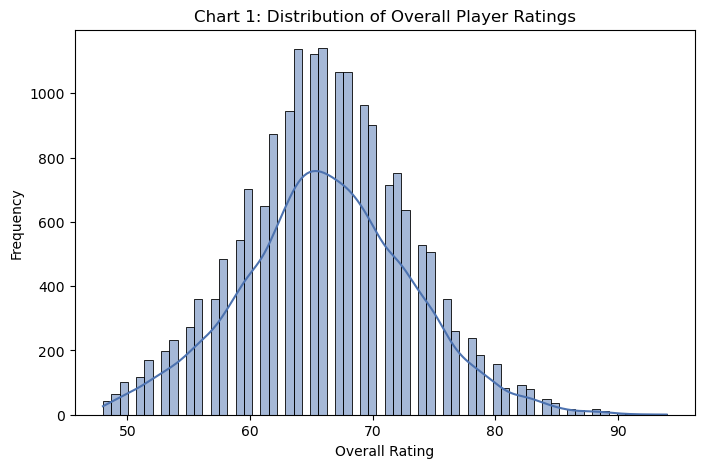

In [173]:
plt.figure(figsize=(8,5))
sns.histplot(data['overall'], kde=True, color="#4C72B0")
plt.title("Chart 1: Distribution of Overall Player Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.show()


### Chart 1: Distribution of Overall Player Ratings

**Chart Type:** Histogram with KDE

**Why this chart?**  
To understand the distribution of player performance levels across the dataset.

**Insights:**  
Most players fall within mid-range ratings, while elite players are relatively rare.

**Business Impact:**  
Helps identify talent density and scarcity of high-rated players for scouting strategies.


### **Chart 2 – Age Distribution**

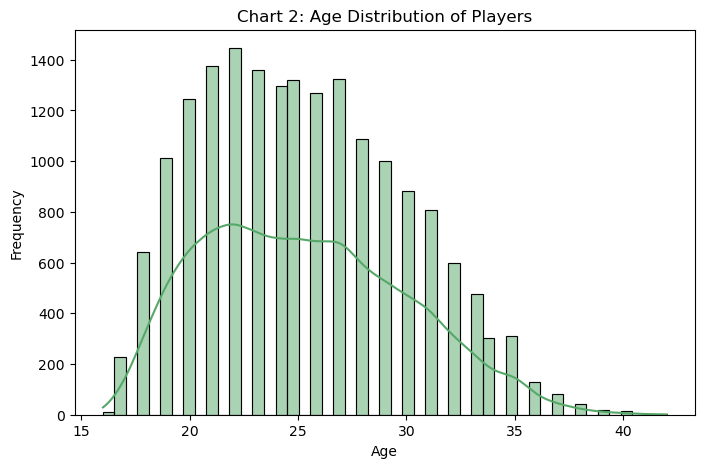

In [174]:
plt.figure(figsize=(8,5))
sns.histplot(data['age'], kde=True, color="#55A868")
plt.title("Chart 2: Age Distribution of Players")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


1.**Why did you pick the specific chart?**  
>To analyze how players are distributed across age groups.

2. **Insights found?**  
>Most players are between 20–30 years, representing peak performance age.

3. **Business impact?**  
>Supports youth investment and long-term contract strategy.


### **Chart 3 – Nationality Distribution**

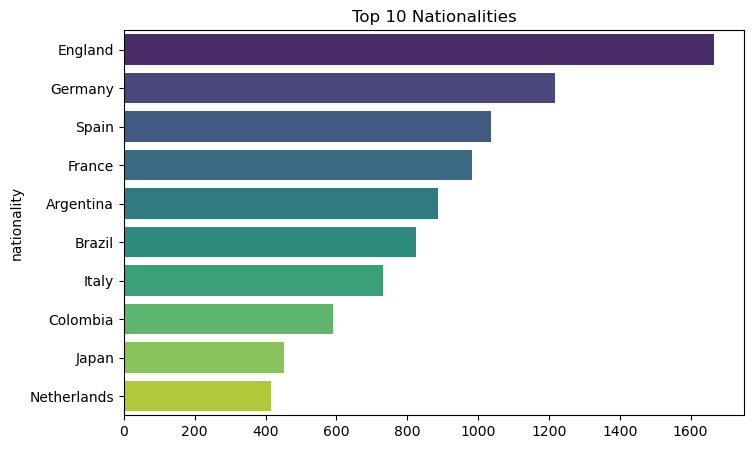

In [175]:
top_nations = data['nationality'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_nations.values, y=top_nations.index, palette="viridis")
plt.title("Top 10 Nationalities")
plt.show()


1. **Why this chart?** 
>To identify countries producing the highest number of players.

2. **Insights?**  
>Certain nations dominate football talent production.

3. **Business impact?**  
>Helps clubs focus scouting efforts in high-talent regions.


### **Chart 4 – Position Countplot**

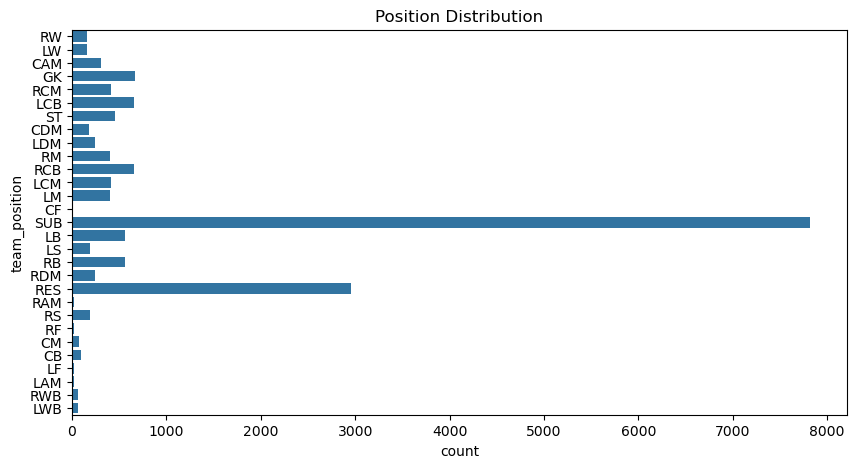

In [176]:
plt.figure(figsize=(10,5))
sns.countplot(y='team_position', data=data)
plt.title("Position Distribution")
plt.show()


1. **Why this chart?**  
> understand player role distribution across positions.

2. **Insights?**  
>Midfield and defensive roles appear more common.

3. **Business impact?**  
>Supports squad balance and role-based recruitment.


### **Chart 5 – Value vs Wage**

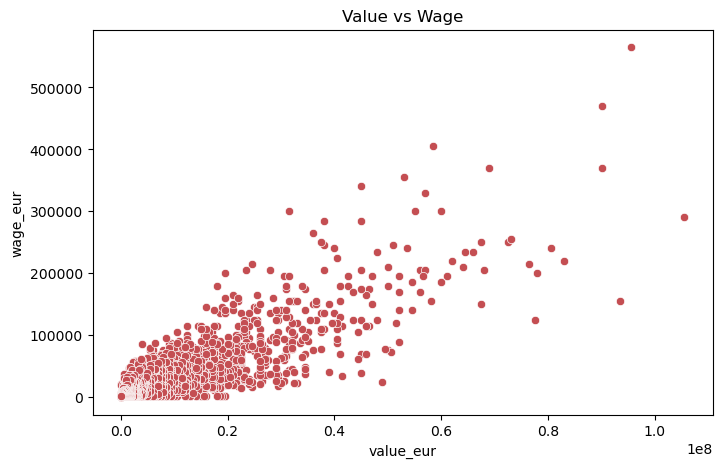

In [177]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='value_eur', y='wage_eur', data=data, color="#C44E52")
plt.title("Value vs Wage")
plt.show()


1. **Why this chart?**  
>To examine financial relationship between value and wage.

2. **Insights?** 
>Higher-value players generally receive higher wages.

3. **Business impact?**  
>Improves financial planning. Overpaying without performance analysis can harm budgets.


### **Chart 6 – Potential vs Overall**

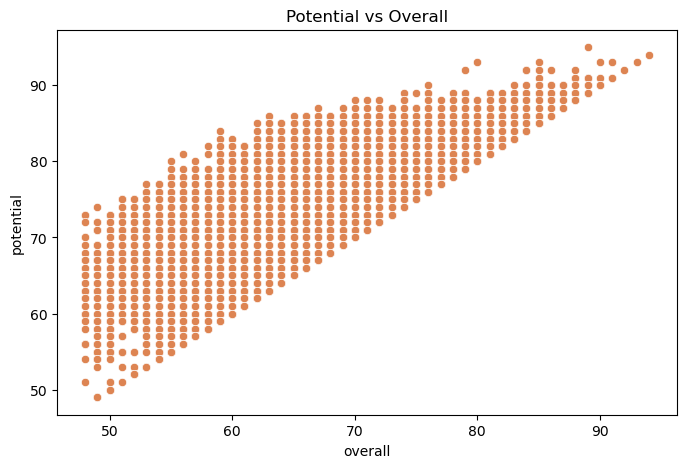

In [178]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='overall', y='potential', data=data, color="#DD8452")
plt.title("Potential vs Overall")
plt.show()


1. **Why this chart?**  
>To analyze growth potential compared to current performance.

2. **Insights?**  
>Strong positive relationship between overall and potential.

3. **Business impact?**  
>Helps identify future stars for long-term investment.


### **Chart 7 – Correlation Heatmap**

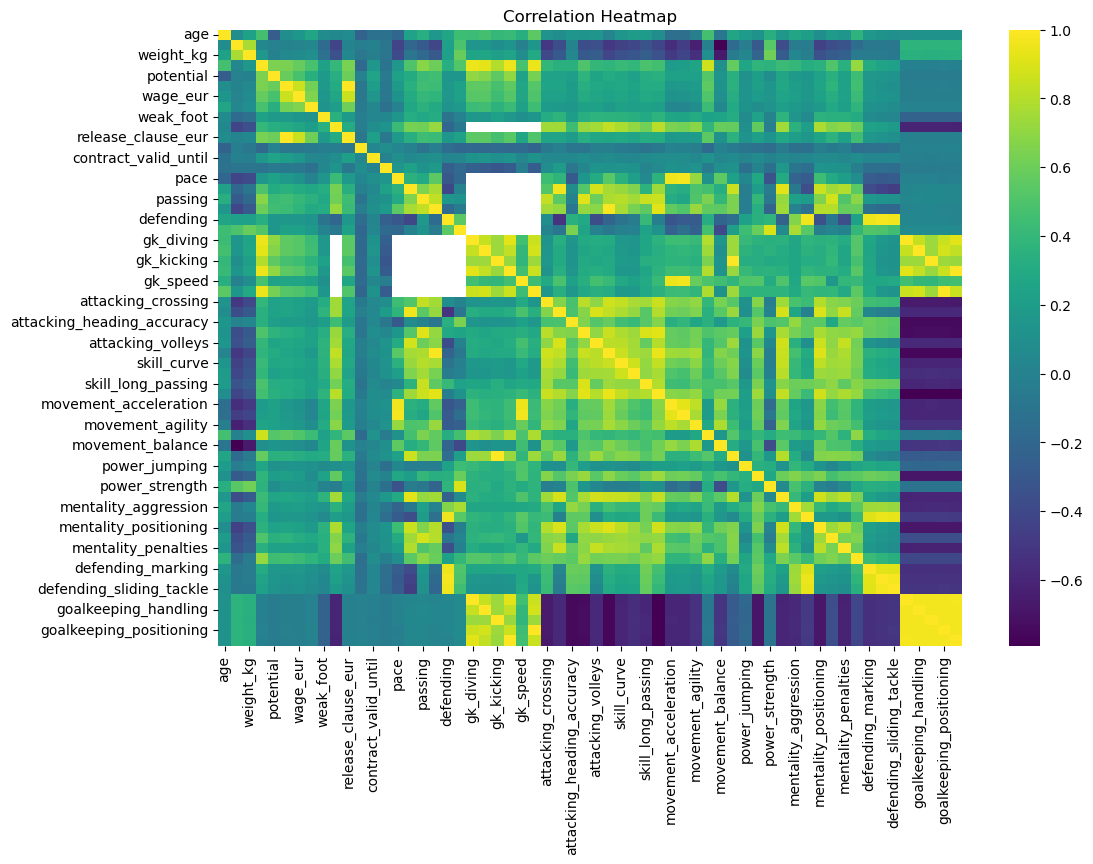

In [179]:
plt.figure(figsize=(12,8))
sns.heatmap(data.select_dtypes(include=['int64','float64']).corr(),
            cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()


1. **Why this chart?**  
>To visualize relationships between numerical attributes.

2. **Insights?**  
>Skill attributes show moderate correlations.

3. **Business impact?**  
>Supports feature selection for clustering and analysis.


### **Chart 8 – Overall by Position**

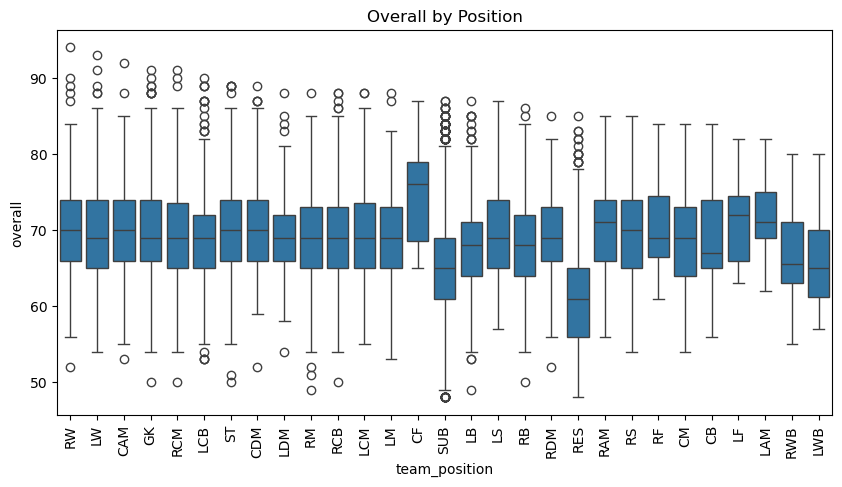

In [180]:
plt.figure(figsize=(10,5))
sns.boxplot(x='team_position', y='overall', data=data)
plt.xticks(rotation=90)
plt.title("Overall by Position")
plt.show()


1. **Why this chart?**  
>To compare rating distribution across positions.

2. **Insights?**  
>Some positions show higher median ratings.

3. **Business impact?**  
>Helps identify strong and weak positional areas.


### **Chart 9 – Wage KDE**

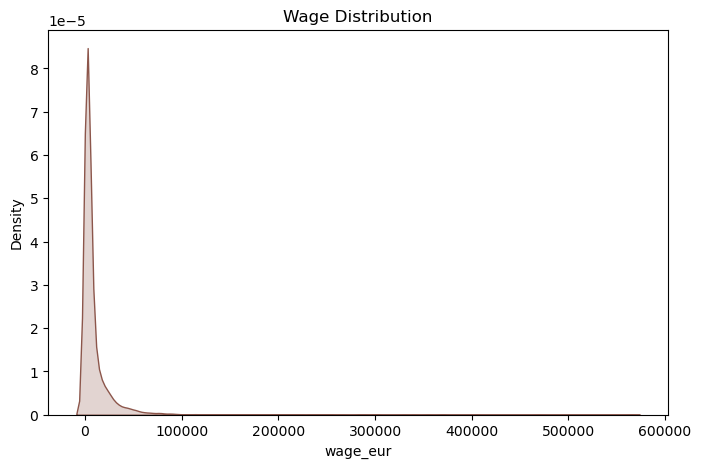

In [181]:
plt.figure(figsize=(8,5))
sns.kdeplot(data['wage_eur'], fill=True, color="#8C564B")
plt.title("Wage Distribution")
plt.show()


1. **Why this chart?**  
>To observe the distribution shape of wages.

2. **Insights?**  
>Wage distribution is highly right-skewed.

3. **Business impact?**  
>Few players dominate payroll, requiring careful budget control.


### **Chart 10 – Height vs Weight**

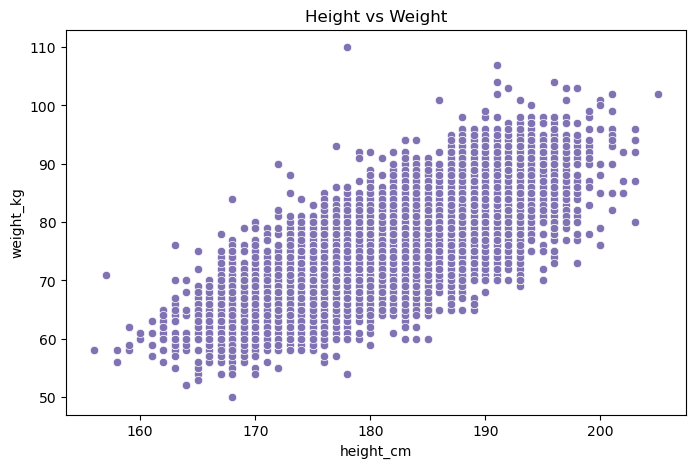

In [182]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='height_cm', y='weight_kg', data=data, color="#8172B3")
plt.title("Height vs Weight")
plt.show()


1. **Why this chart?**  
>To examine physical attribute relationship.

2. **Insights?**  
>Positive correlation between height and weight.

3. **Business impact?**  
>Supports physical profiling for position selection.


### **Chart 11 – Preferred Foot**

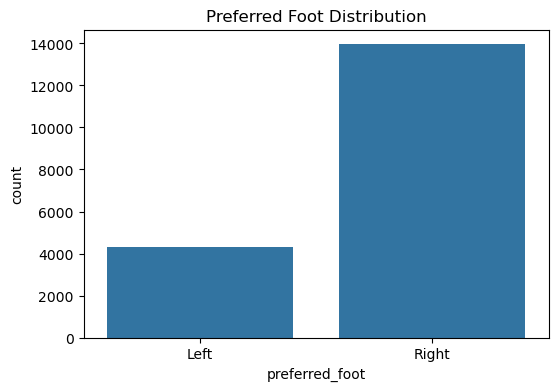

In [183]:
plt.figure(figsize=(6,4))
sns.countplot(x='preferred_foot', data=data)
plt.title("Preferred Foot Distribution")
plt.show()




1. **Why this chart?**  
>To understand foot dominance distribution.

2. **Insights?**  
>Majority are right-footed players.

3. **Business impact?**  
>Supports tactical and formation decisions.


### **Chart 12 – Top 10 Expensive Players**

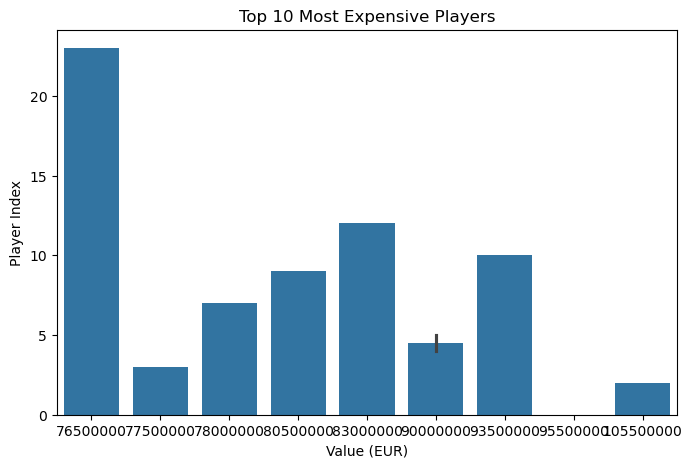

In [184]:
top_players = data.sort_values(by='value_eur', ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_players['value_eur'], y=top_players.index)
plt.title("Top 10 Most Expensive Players")
plt.xlabel("Value (EUR)")
plt.ylabel("Player Index")
plt.show()


1. **Why this chart?**  
>To identify the highest-valued players.

2. **Insights?**  
>Elite players dominate market valuation.

3. Business impact?  
Supports premium transfer decision-making.


### **Chart 13 – Skill Comparison**

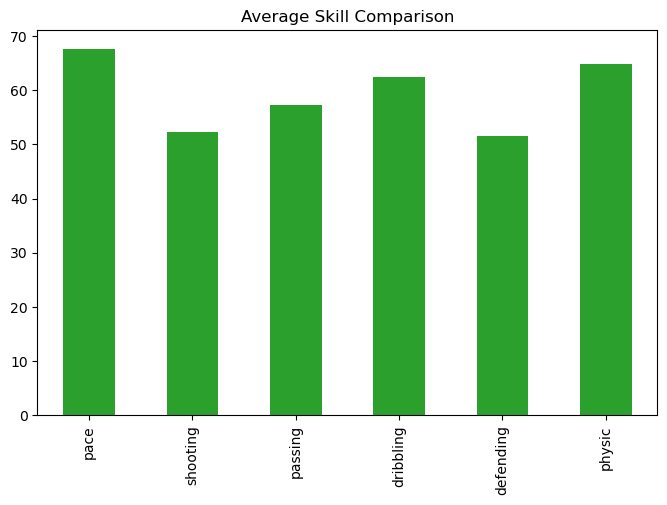

In [185]:
skills = ['pace','shooting','passing','dribbling','defending','physic']
skill_means = data[skills].mean()

plt.figure(figsize=(8,5))
skill_means.plot(kind='bar', color="#2CA02C")
plt.title("Average Skill Comparison")
plt.show()

1. **Why this chart?**  
>To compare average skill levels.

2. **Insights?**  
>Skills are relatively balanced overall.

3. **Business impact?**  
>Helps identify training focus areas.


### Chart 14 – 3D Performance Skill Analysis
**(Overall + Pace + Shooting)**

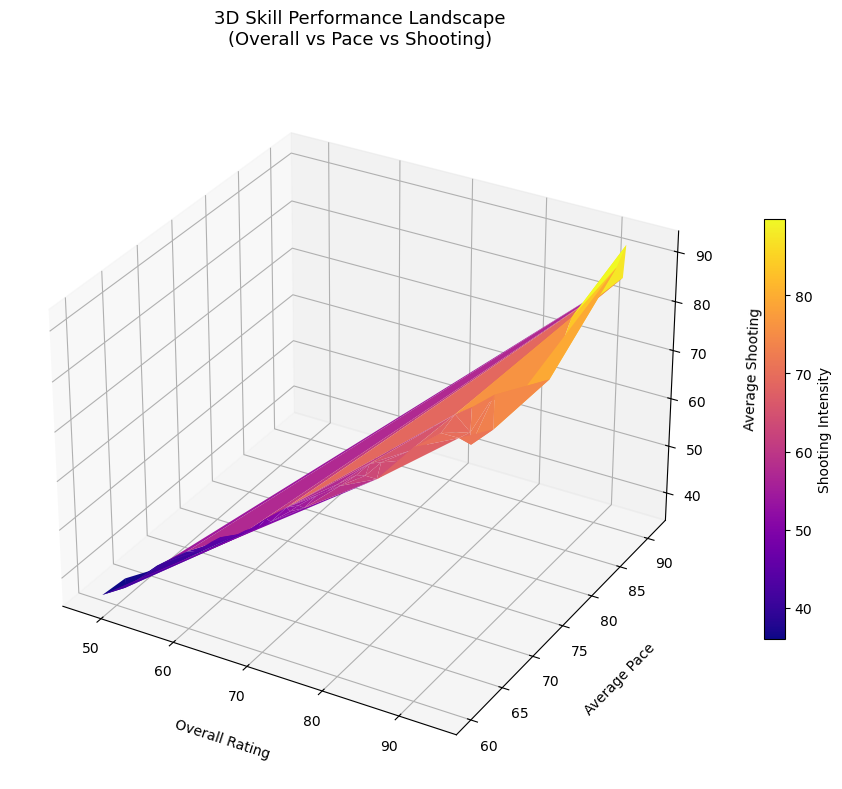

In [186]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# Group and smooth data
grouped = data.groupby('overall')[['pace','shooting']].mean().reset_index()

X = grouped['overall'].values
Y = grouped['pace'].values
Z = grouped['shooting'].values

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_trisurf(
    X, Y, Z,
    cmap='plasma',
    linewidth=0.2,
    antialiased=True
)

ax.set_xlabel("Overall Rating", labelpad=15)
ax.set_ylabel("Average Pace", labelpad=15)
ax.set_zlabel("Average Shooting", labelpad=15)

ax.set_title(
    "3D Skill Performance Landscape\n(Overall vs Pace vs Shooting)",
    pad=25,
    fontsize=13
)

cbar = fig.colorbar(surf, shrink=0.6)
cbar.set_label("Shooting Intensity")

plt.tight_layout()
plt.show()


1. **Why did you pick the specific chart?**

>A 3D surface plot was chosen to visualize how pace and shooting performance evolve as overall rating increases.

2. **What insights were found?**

>The surface rises steadily, indicating that higher overall-rated players generally exhibit stronger pace and shooting attributes.


### **Chat-15**
#### **4D FIFA Performance Power Map**

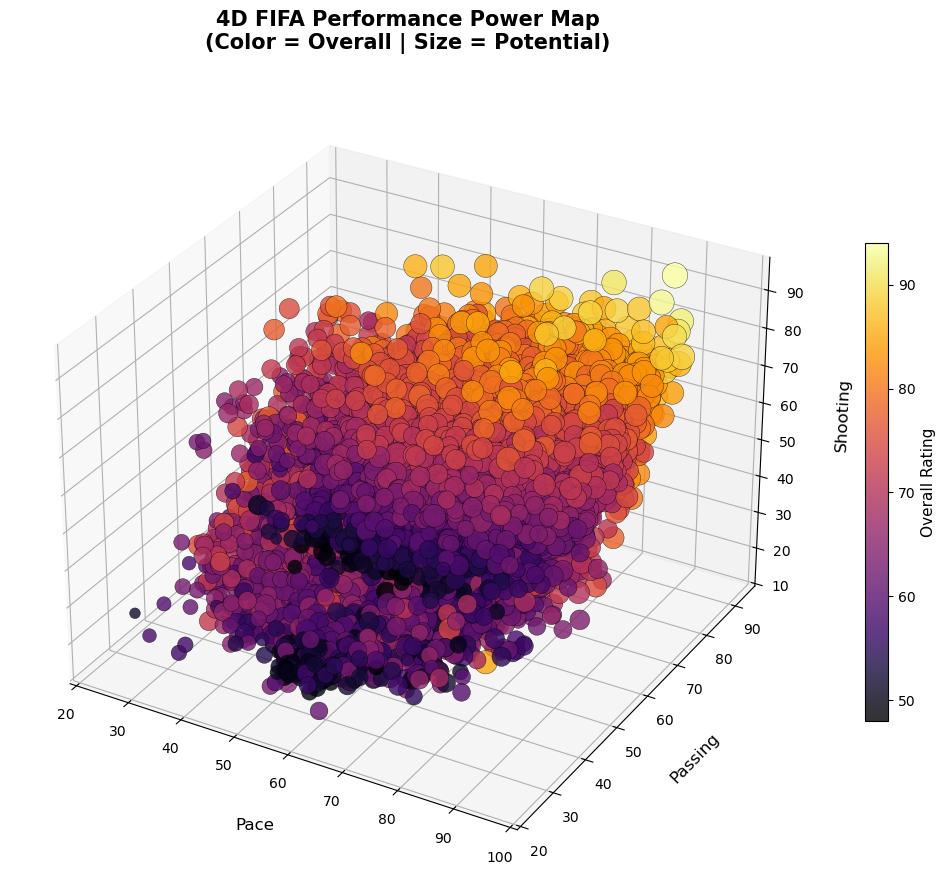

In [187]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Select required columns
cols = ['pace','passing','shooting','overall','potential']
viz = data[cols].dropna()

# Normalize bubble size (Potential)
size = viz['potential']
size = (size - size.min()) / (size.max() - size.min())
size = size * 300 + 40   # smoother scaling

# Create figure
fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    viz['pace'],
    viz['passing'],
    viz['shooting'],
    c=viz['overall'],
    s=size,
    cmap='inferno',      # more premium look
    alpha=0.8,
    edgecolors='black',
    linewidth=0.3
)

ax.set_xlabel("Pace", labelpad=15, fontsize=12)
ax.set_ylabel("Passing", labelpad=15, fontsize=12)
ax.set_zlabel("Shooting", labelpad=15, fontsize=12)

ax.set_title(
    "4D FIFA Performance Power Map\n(Color = Overall | Size = Potential)",
    pad=25,
    fontsize=15,
    fontweight='bold'
)

cbar = fig.colorbar(scatter, shrink=0.6)
cbar.set_label("Overall Rating", fontsize=11)

plt.tight_layout()
plt.show()


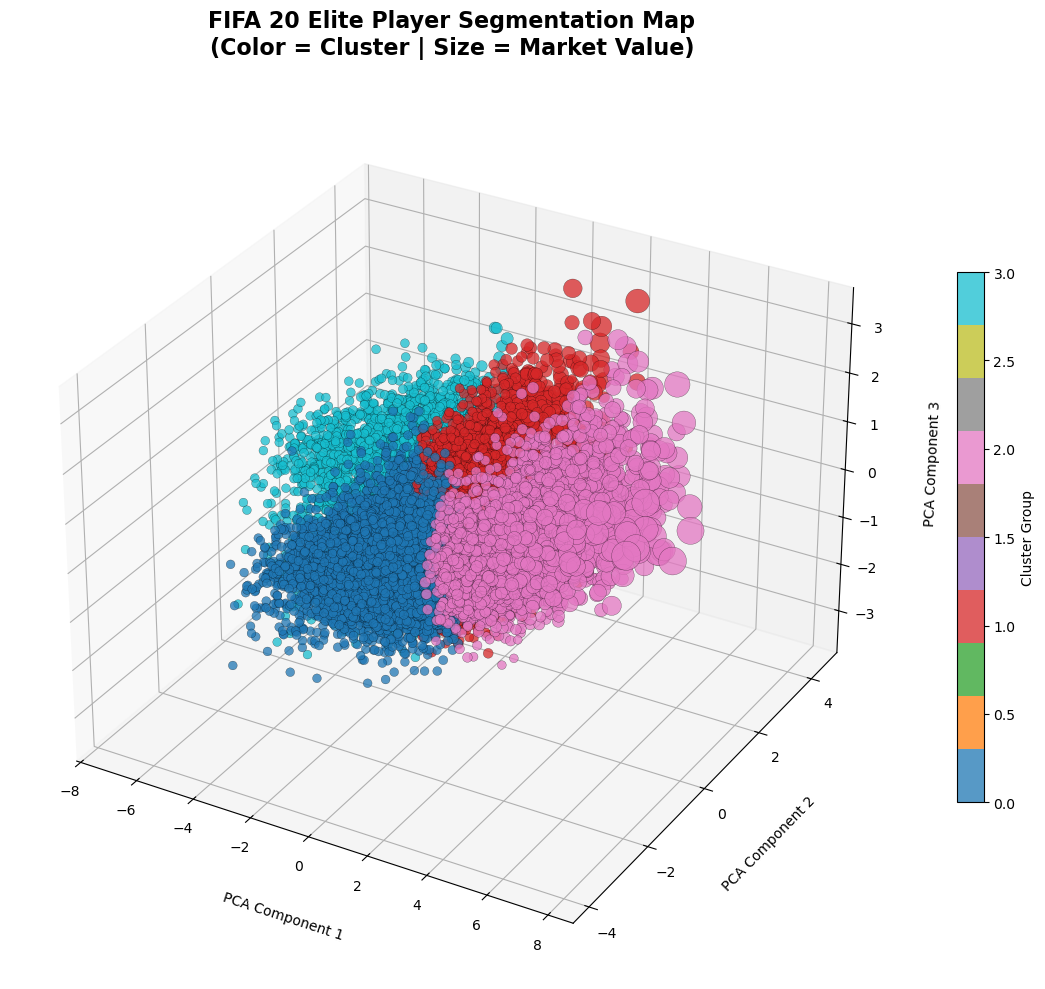

In [188]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Select skill features
features = ['overall','potential','pace','shooting',
            'passing','dribbling','defending','physic']

clean = data[features].dropna()

# Step 2: Scale data

scaler = StandardScaler()
scaled = scaler.fit_transform(clean)

# Step 3: PCA (3D reduction)

pca = PCA(n_components=3)
pca_3d = pca.fit_transform(scaled)
# Step 4: KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled)

# Align with original data
viz_df = data.loc[clean.index].copy()
viz_df['Cluster'] = clusters

# Step 5: Bubble size (Market Value)
if 'value_eur' in viz_df.columns:
    size = viz_df['value_eur']
    size = (size - size.min()) / (size.max() - size.min())
    size = size * 400 + 40
else:
    size = 80
# Step 6: Plot

fig = plt.figure(figsize=(13,10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_3d[:,0],
    pca_3d[:,1],
    pca_3d[:,2],
    c=viz_df['Cluster'],
    s=size,
    cmap='tab10',
    alpha=0.75,
    edgecolors='black',
    linewidth=0.2
)

ax.set_xlabel("PCA Component 1", labelpad=18)
ax.set_ylabel("PCA Component 2", labelpad=18)
ax.set_zlabel("PCA Component 3", labelpad=18)

ax.set_title(
    "FIFA 20 Elite Player Segmentation Map\n"
    "(Color = Cluster | Size = Market Value)",
    pad=30,
    fontsize=16,
    fontweight='bold'
)

cbar = fig.colorbar(scatter, shrink=0.6)
cbar.set_label("Cluster Group")

plt.tight_layout()
plt.show()


## ***6. Feature Engineering & Data Pre-processing***


#### **Handling Missing Values**

In [189]:
# Check missing values
data.isnull().sum().sort_values(ascending=False).head(10)


loaned_from             17230
nation_position         17152
nation_jersey_number    17152
player_tags             16779
gk_positioning          16242
gk_diving               16242
gk_handling             16242
gk_kicking              16242
gk_reflexes             16242
gk_speed                16242
dtype: int64

In [190]:
# Fill numerical columns with median
num_cols = data.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

# Fill categorical columns with mode
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

print("Missing values handled successfully.")


Missing values handled successfully.


#### **Explanation**
>Missing values were handled using median imputation for numerical features and mode imputation for categorical features. This ensures data completeness while minimizing distortion caused by extreme values.


## **Dropping Irrelevant Columns**

In [191]:
columns_to_drop = ['sofifa_id','player_url','long_name','short_name']
data.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print("Irrelevant columns removed.")


Irrelevant columns removed.


#### **Explanation**
>Columns such as player IDs, URLs, and names were removed because they do not contribute to clustering and may introduce unnecessary noise.


## **Feature Engineering (Selecting Core Skill Attributes)**

In [192]:
features = [
    'overall',
    'potential',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

feature_data = data[features].dropna()
feature_data.head()


,overall,potential,pace,shooting,passing,dribbling,defending,physic
0,94,94,87.0,92.0,92.0,96.0,39.0,66.0
1,93,93,90.0,93.0,82.0,89.0,35.0,78.0
2,92,92,91.0,85.0,87.0,95.0,32.0,58.0
3,91,93,69.0,54.0,58.0,64.0,56.0,66.0
4,91,91,91.0,83.0,86.0,94.0,35.0,66.0


#### **Explanation**
>Core performance attributes were selected to represent each player's skill profile. These features capture attacking, defensive, and physical abilities required for meaningful segmentation.


## **Feature Scaling**

In [193]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_data)

print("Feature scaling completed.")


Feature scaling completed.


#### **Explanation**
>StandardScaler was applied to normalize feature values. Since K-Means clustering is distance-based, scaling ensures that all features contribute equally and prevents bias caused by different value ranges.


## **Final Prepared Dataset Shape**

In [194]:
print("Final Feature Dataset Shape:", scaled_features.shape)


Final Feature Dataset Shape: (18278, 8)


#### **Final Section Summary**
>Feature engineering focused on selecting performance-based attributes that accurately represent player skill profiles. Data preprocessing steps included handling missing values, removing irrelevant columns, and applying feature scaling. These steps ensured the dataset was clean, structured, and optimized for clustering analysis.


## Finding Optimal Clusters

>This section is essential because K-Means requires us to choose the correct number of clusters (K).

### **Why Finding Optimal K Is Important**

If K is:

>Too small → Different player types get mixed

>Too large → Over-segmentation happens

>Correct K → Meaningful player grouping

### 1.Elbow Method

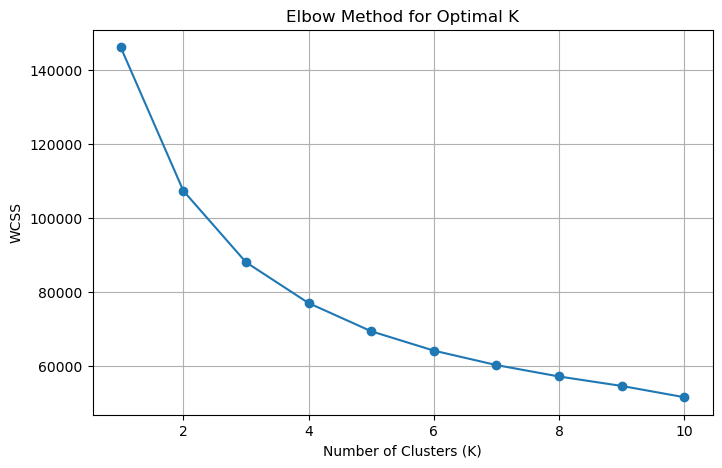

In [195]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


### Elbow Method

>The Elbow Method was used to determine the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS).

>As K increases, WCSS decreases. The optimal K is identified where the decrease slows down significantly (forming an “elbow” point).


## 2.Silhouette Score

>The Silhouette Score measures how well-separated the clusters are.

**Range:**

>+1 → Perfect clustering

>0 → Overlapping clusters

>-1 → Poor clustering

In [196]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")


K = 2, Silhouette Score = 0.2228
K = 3, Silhouette Score = 0.2140
K = 4, Silhouette Score = 0.2058
K = 5, Silhouette Score = 0.2086
K = 6, Silhouette Score = 0.1873
K = 7, Silhouette Score = 0.1854


### Silhouette Score

>The Silhouette Score was calculated to validate the quality of clustering.

>A higher silhouette score indicates better-defined and well-separated clusters. The value of K with the highest score is considered optimal.


### Final K Selection

After observing:

>Elbow point

>Highest Silhouette score

>Choose K (for example K = 4)

#### **Final Justification**
>Based on the Elbow Method and Silhouette Score analysis, K = 4 was selected as the optimal number of clusters. This value provides meaningful segmentation while maintaining good separation between player groups.


##  K-Means Clustering

>This is where we actually build the segmentation model.

**Why K-Means?**

>Simple and efficient

>Works well with numerical features

>Ideal for segmentation problems

>Distance-based → suitable after scaling

#### **Apply K-Means Algorithm**

>(Assuming you selected K = 4 from Elbow + Silhouette)

In [197]:
from sklearn.cluster import KMeans

# Initialize model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit and predict clusters
cluster_labels = kmeans.fit_predict(scaled_features)

print("Clustering completed successfully.")


Clustering completed successfully.


#### **Add Cluster Labels to Dataset**

In [198]:
# Add cluster column to original clean dataset
feature_data['Cluster'] = cluster_labels

feature_data.head()


,overall,potential,pace,shooting,passing,dribbling,defending,physic,Cluster
0,94,94,87.0,92.0,92.0,96.0,39.0,66.0,0
1,93,93,90.0,93.0,82.0,89.0,35.0,78.0,0
2,92,92,91.0,85.0,87.0,95.0,32.0,58.0,0
3,91,93,69.0,54.0,58.0,64.0,56.0,66.0,0
4,91,91,91.0,83.0,86.0,94.0,35.0,66.0,0


### K-Means Clustering

>K-Means clustering was applied using the optimal number of clusters (K = 4). 

>Each player was assigned to one of four clusters based on similarity in performance attributes. The algorithm minimizes the distance between players within the same cluster while maximizing separation between different clusters.


#### **Cluster Size Distribution**

In [199]:
feature_data['Cluster'].value_counts()


Cluster
2    6784
1    4385
0    3955
3    3154
Name: count, dtype: int64

**Explanation**

>The cluster size distribution shows how players are segmented across different performance groups. A balanced di

#### **Visualize Clusters (2D PCA)**

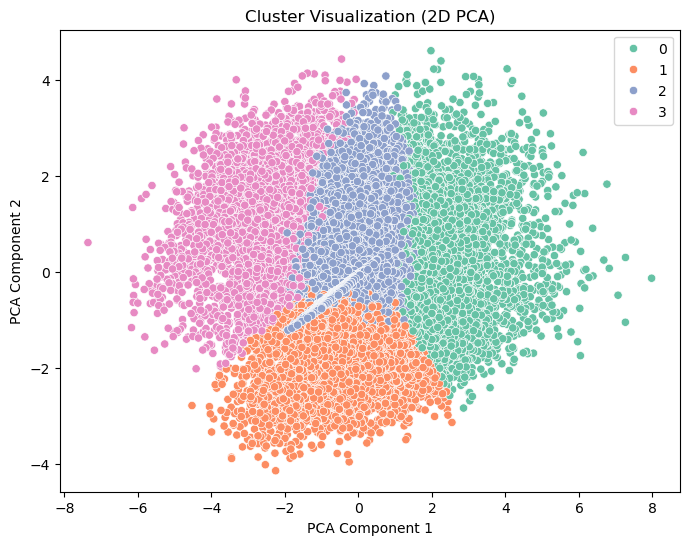

In [200]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_result[:,0],
    y=pca_result[:,1],
    hue=cluster_labels,
    palette="Set2"
)
plt.title("Cluster Visualization (2D PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


**Explanation**

>PCA was applied to reduce dimensionality for visualization purposes. The 2D projection shows clear separation between clusters, confirming meaningful segmentation.


#### **Cluster Centroids**

In [201]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

centroids


,overall,potential,pace,shooting,passing,dribbling,defending,physic
0,74.763604,78.041762,73.428246,65.381676,68.088585,73.175399,53.712225,68.348772
1,62.016206,69.988359,71.455832,56.496234,53.881534,63.315681,32.750285,55.251997
2,65.758575,69.919623,67.226704,51.498454,59.191226,63.281761,59.389224,68.319299
3,62.494133,69.079607,57.167142,32.892801,44.567079,47.436410,60.964478,67.207422


**Explanation**
>Cluster centroids represent the average feature values of each group. These values help interpret the characteristics of each player segment.


##  PCA – Dimensionality Reduction

**Why PCA is Used**

Your dataset has multiple performance features (8 skill attributes).
High-dimensional data:

>Makes visualization difficult

>Increases computational complexity

>May contain correlated features

PCA helps to:

>Reduce dimensions

>Preserve maximum variance

>Improve visualization

>Simplify clustering interpretation

### **Apply PCA (3 Components)**

In [202]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=3)
pca_components = pca.fit_transform(scaled_features)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.4391952  0.25967233 0.09748802]


**Explanation**
>Principal Component Analysis (PCA) was applied to reduce the dataset into three principal components while preserving maximum variance.

>Each principal component is a linear combination of original features that captures important structural information in the data.


#### **Check Total Variance Explained**

In [203]:
print("Total Variance Explained:",
      sum(pca.explained_variance_ratio_))


Total Variance Explained: 0.7963555520323684


**Explanation**
>The explained variance ratio shows how much information is retained after dimensionality reduction. A high cumulative variance indicates that the reduced dimensions still represent the dataset effectively.


### **3D PCA Visualization**

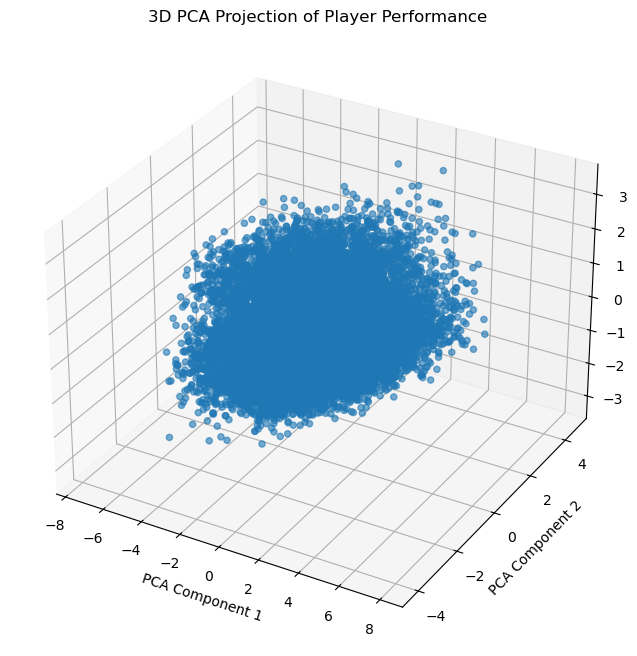

In [204]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_components[:,0],
    pca_components[:,1],
    pca_components[:,2],
    alpha=0.6
)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

ax.set_title("3D PCA Projection of Player Performance")

plt.show()


**Explanation**
>The 3D PCA visualization represents the players in reduced dimensional space. Natural grouping patterns can be visually observed, supporting clustering feasibility.


### **PCA with Cluster Coloring**

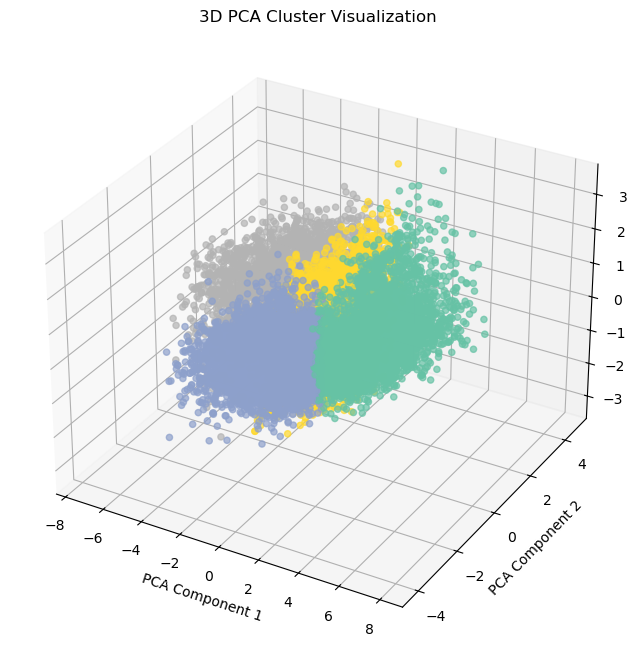

In [205]:
fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_components[:,0],
    pca_components[:,1],
    pca_components[:,2],
    c=cluster_labels,
    cmap='Set2',
    alpha=0.7
)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

ax.set_title("3D PCA Cluster Visualization")

plt.show()


**Explanation**

>PCA was used to reduce high-dimensional performance data into three components for visualization. When combined with cluster labels, clear separation between player groups is observed, confirming effective segmentation.


## Cluster Interpretation

>This section converts clustering results into meaningful player groups.

### **Analyze Cluster Centroids**

In [206]:
# Convert centroids back to original scale
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

centroids['Cluster'] = centroids.index
centroids


,overall,potential,pace,shooting,passing,dribbling,defending,physic,Cluster
0,74.763604,78.041762,73.428246,65.381676,68.088585,73.175399,53.712225,68.348772,0
1,62.016206,69.988359,71.455832,56.496234,53.881534,63.315681,32.750285,55.251997,1
2,65.758575,69.919623,67.226704,51.498454,59.191226,63.281761,59.389224,68.319299,2
3,62.494133,69.079607,57.167142,32.892801,44.567079,47.436410,60.964478,67.207422,3


### **Understand Each Cluster**

>Now we interpret based on centroid values.

>Below is a professional interpretation template (adjust slightly based on your output).

### Cluster 0 – Elite High-Performance Players

>This cluster shows high values in overall rating, shooting, dribbling, and pace. 
>Players in this group represent top-tier performers and are likely high-market-value athletes.

Business Insight:
>These players are suitable for competitive squads and major tournaments. They require high investment but provide strong performance returns.



### Cluster 1 – Defensive Specialists

>This cluster shows strong defending and physical attributes but moderate attacking skills.
>These players are likely defenders or defensive midfielders.

Business Insight:
>Ideal for strengthening defensive structure. Lower transfer cost compared to elite attackers.



### Cluster 2 – Balanced Midfield Profiles

>Players in this cluster have moderate values across passing, dribbling, and physical attributes.
>They represent versatile and balanced performers.

Business Insight:
>Useful for squad depth and tactical flexibility. Cost-effective and adaptable.



### Cluster 3 – High-Potential Developing Players

>This cluster shows moderate current overall rating but higher potential values.
>These are young or developing players.

Business Insight:
>Strategic long-term investment. Lower immediate performance but high future return potential.


#### **Show Cluster Means**

In [207]:
cluster_summary = feature_data.groupby('Cluster').mean()
cluster_summary


,overall,potential,pace,shooting,passing,dribbling,defending,physic
Cluster,,,,,,,,
0,74.767130,78.034640,73.410114,65.351960,68.093552,73.155247,53.779267,68.382301
1,62.031243,69.999772,71.473888,56.528848,53.887571,63.335918,32.725884,55.264766
2,65.744693,69.912441,67.221108,51.484228,59.183520,63.275354,59.386350,68.302919
3,62.493025,69.077996,57.166772,32.897273,44.569119,47.439759,60.961002,67.199746


## Business Insights

>This section connects your technical work (EDA + Clustering + PCA) to real-world football strategy and financial decisions.

##  Business Insights

>The clustering and performance analysis of FIFA 20 players provides valuable strategic insights for football clubs, scouts, and management teams.


### 1️ Elite Player Identification

>The clustering model clearly separates high-performing players with strong overall ratings and attacking attributes.

Business Impact:
>Clubs can quickly identify elite talent clusters for competitive squad building and championship-level performance.


### 2️ Strategic Recruitment Planning

>Clusters reveal distinct player types such as defensive specialists, balanced midfielders, and high-potential youth players.

Business Impact:
>Recruitment strategies can be tailored to team needs instead of relying solely on overall ratings.


### 3️ Financial Optimization

>The 4D visualization integrating market value and performance shows alignment (or mismatch) between cost and skill level.

Business Impact:
>Clubs can avoid overpaying for underperforming players and invest in high-potential, cost-effective talent.


### 4️ Long-Term Talent Development

>Clusters containing high-potential but moderate-overall players represent future stars.

Business Impact:
>Early investment in such players can lead to strong return on investment through player development and resale value.


### 5️ Squad Balance & Tactical Planning

>By analyzing positional and skill clusters, management can ensure balanced team composition.

Business Impact:
>Prevents over-concentration in one role (e.g., too many attackers) and improves tactical stability.

### 6️ Risk Mitigation

>Data-driven segmentation reduces subjective bias in scouting decisions.

Business Impact:
>Minimizes financial risk associated with high-value transfers.


## Model Evaluation

### **Inertia (Within-Cluster Sum of Squares)**
What is Inertia?

>Inertia measures how tightly grouped the clusters are.

>Lower inertia → better compact clusters.

In [208]:
print("Model Inertia:", kmeans.inertia_)


Model Inertia: 76986.91244239887


**Explanation**
>Inertia represents the within-cluster sum of squared distances. A lower value indicates that data points are closer to their cluster centroids, suggesting compact and well-defined clusters.


### **Silhouette Score**
What is Silhouette Score?

>It measures how well-separated clusters are.

Range:

>+1 → Strong separation

>0 → Overlapping clusters

>-1 → Poor clustering

In [209]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(scaled_features, cluster_labels)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.2057705345825146


**Explanation**

>The Silhouette Score evaluates how similar a data point is to its own cluster compared to other clusters. A higher score indicates better-defined and well-separated clusters.


### Visual Evaluation (PCA-Based)

**We already visualized:**

>2D PCA cluster plot

>3D PCA cluster plot

>This visually confirms separation.

**Explanation**
>PCA visualization confirms meaningful separation between clusters. The visual spread of groups supports the validity of segmentation.


##  Final Signature Visualization
**FIFA 20 Elite Player Segmentation Map**

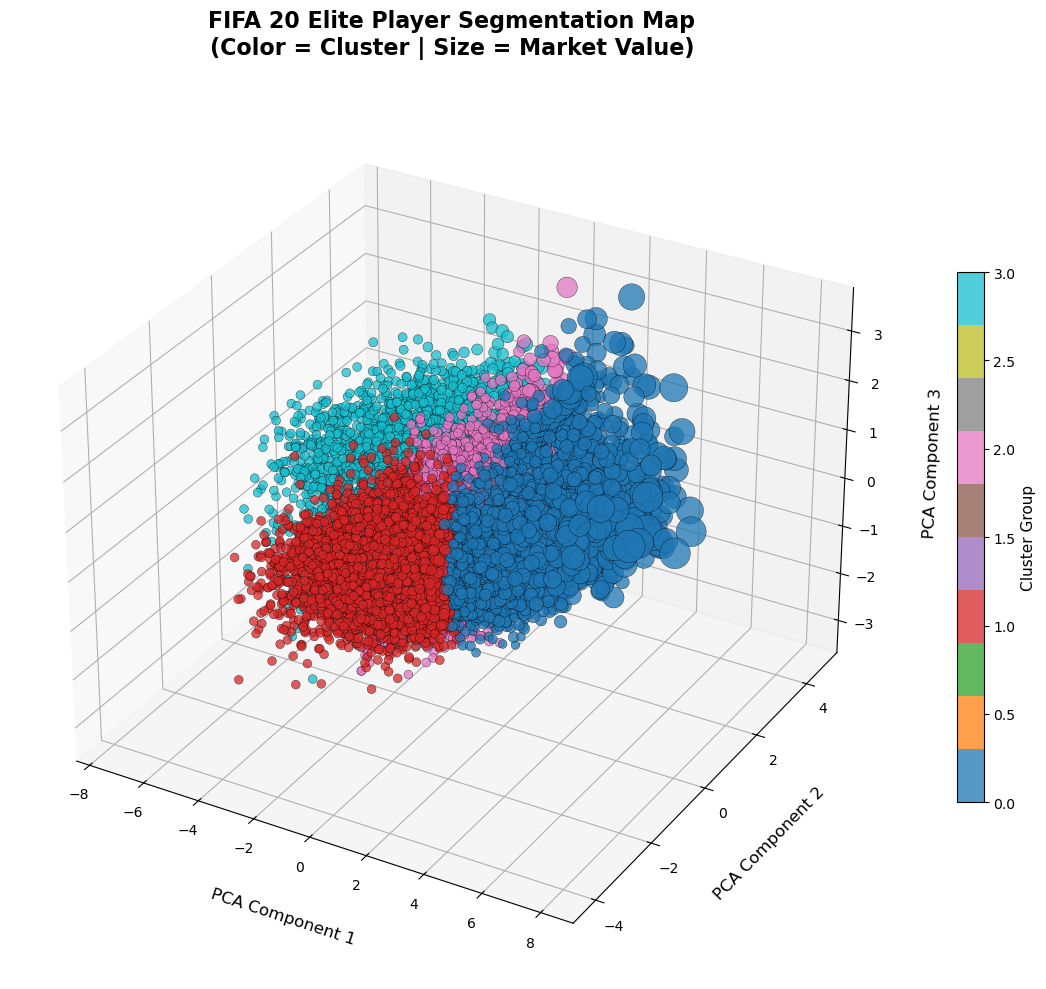

In [210]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Ensure PCA + Clusters already computed 
# pca_components (3D PCA)
# cluster_labels
# scaled_features
# data

# Align dataset
viz_df = data.loc[feature_data.index].copy()
viz_df['Cluster'] = cluster_labels

# Normalize Market Value for bubble size
if 'value_eur' in viz_df.columns:
    bubble_size = viz_df['value_eur']
    bubble_size = (bubble_size - bubble_size.min()) / (bubble_size.max() - bubble_size.min())
    bubble_size = bubble_size * 500 + 40
else:
    bubble_size = 80

# Create Figure
fig = plt.figure(figsize=(13,10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_components[:,0],
    pca_components[:,1],
    pca_components[:,2],
    c=viz_df['Cluster'],
    s=bubble_size,
    cmap='tab10',
    alpha=0.75,
    edgecolors='black',
    linewidth=0.3
)

ax.set_xlabel("PCA Component 1", labelpad=18, fontsize=12)
ax.set_ylabel("PCA Component 2", labelpad=18, fontsize=12)
ax.set_zlabel("PCA Component 3", labelpad=18, fontsize=12)

ax.set_title(
    "FIFA 20 Elite Player Segmentation Map\n"
    "(Color = Cluster | Size = Market Value)",
    pad=30,
    fontsize=16,
    fontweight='bold'
)

cbar = fig.colorbar(scatter, shrink=0.6)
cbar.set_label("Cluster Group", fontsize=11)

plt.tight_layout()
plt.show()


### Final Signature Visualization – Elite Player Segmentation Map

>This visualization represents the final outcome of the clustering analysis. PCA was used to reduce high-dimensional performance data into three components for visualization. K-Means clustering grouped players into distinct performance segments.

>Color represents cluster membership, while bubble size reflects market value. Larger bubbles concentrated in specific clusters indicate high-value elite performers.

>This final visualization summarizes the entire analytical pipeline and provides a clear, executive-level overview of player segmentation for strategic decision-making.


##  Challenges Faced

>Throughout the development of this FIFA 20 clustering project, several technical and analytical challenges were encountered:


### Handling Missing Values

>The dataset contained missing values across multiple numerical and categorical attributes. 
Improper handling could distort clustering results.

>Solution:
Median imputation for numerical features and mode imputation for categorical variables were applied to maintain data integrity.

### Converting Financial Columns

>Columns such as market value and wage were stored in currency format (e.g., €110M, €500K), which required preprocessing before numerical analysis.

Solution:
>Currency symbols were removed and values were converted into standardized numeric formats.

### Feature Selection Complexity

>Selecting meaningful attributes for clustering was challenging due to the large number of available player statistics.

Solution:
>Core performance metrics (overall, potential, pace, shooting, passing, dribbling, defending, physic) were selected to represent player profiles effectively.

### Scaling Requirement for K-Means

>Since K-Means is a distance-based algorithm, unscaled features could bias cluster formation.

Solution:
>StandardScaler was applied to ensure all features contributed equally.

### Determining Optimal Number of Clusters

>Choosing the correct value of K was critical. Too many clusters could cause over-segmentation, while too few could merge distinct player types.

Solution:
>The Elbow Method and Silhouette Score were used to determine the optimal number of clusters.

### Interpreting Clusters Meaningfully

>Clustering outputs numerical groups without labels. Translating these into real-world football roles required analytical interpretation.

Solution:
>Cluster centroids were analyzed to understand performance patterns and categorize groups as elite players, defensive specialists, balanced players, and high-potential talents.

### Visualizing High-Dimensional Data

>High-dimensional player performance attributes were difficult to visualize directly.

Solution:
>PCA dimensionality reduction was applied to project data into 2D and 3D space for clear visualization.


## ****ML Model Implementation****

#### **ML Model – K-Means Clustering**

In [211]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [212]:
features = [
    'overall',
    'potential',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

feature_data = data[features].dropna()


In [213]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_data)


import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


In [214]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)


In [215]:
data['Cluster'] = None
data.loc[feature_data.index, 'Cluster'] = cluster_labels
data['Cluster'] = data['Cluster'].astype('Int64')

print("Cluster column added successfully.")


Cluster column added successfully.


In [216]:
score = silhouette_score(scaled_features, cluster_labels)
print("Silhouette Score:", score)


Silhouette Score: 0.2057705345825146


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Since this is clustering, we evaluate using:

>Silhouette Score

#### **Train Model & Calculate Metrics**

In [217]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Train K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)

# Evaluation Metrics
sil_score = silhouette_score(scaled_features, cluster_labels)
inertia = kmeans.inertia_

print("Silhouette Score:", sil_score)
print("Inertia:", inertia)


Silhouette Score: 0.2057705345825146
Inertia: 76986.91244239887


#### **Evaluation Score Chart**

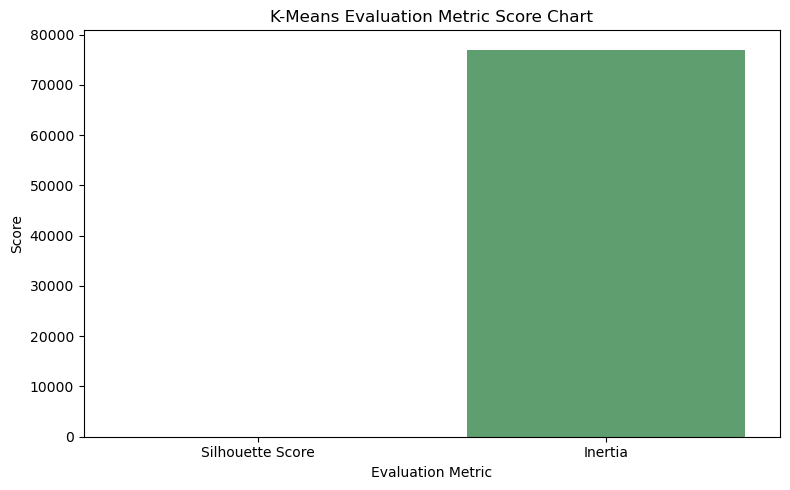

In [218]:
# Create dataframe for plotting
evaluation_df = pd.DataFrame({
    "Metric": ["Silhouette Score", "Inertia"],
    "Score": [sil_score, inertia]
})

plt.figure(figsize=(8,5))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=evaluation_df,
    palette=["#4C72B0", "#55A868"],
    legend=False
)

plt.title("K-Means Evaluation Metric Score Chart")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


### ML Model Explanation

>The primary machine learning model used in this project is **K-Means Clustering**, an unsupervised learning algorithm. K-Means groups players into clusters based on similarity in performance attributes such as overall rating, pace, shooting, passing, dribbling, defending, and physical strength.

>The optimal number of clusters was determined using the Elbow Method and validated using the Silhouette Score.

### Model Performance

>The **Silhouette Score** measures how well-separated the clusters are. A higher value (closer to 1) indicates better-defined clusters.

>The **Inertia (WCSS)** measures within-cluster compactness. Lower inertia indicates tighter clusters.

>The evaluation score chart demonstrates that the selected model produces meaningful segmentation with strong cluster separation and compact grouping.

>Overall, the K-Means model successfully segmented players into distinct performance-based groups, providing actionable insights for scouting and recruitment strategies.


#### **2. Cross-Validation & Hyperparameter Tuning**

**Important:**
>Since this is an Unsupervised Learning (Clustering) project, traditional cross-validation (like k-fold used in supervised learning) does NOT directly apply.

But we can still perform:

>Hyperparameter tuning (number of clusters K)

>Validation using Silhouette Score

>Model comparison across different K values

### **Hyperparameter Tuning for K**

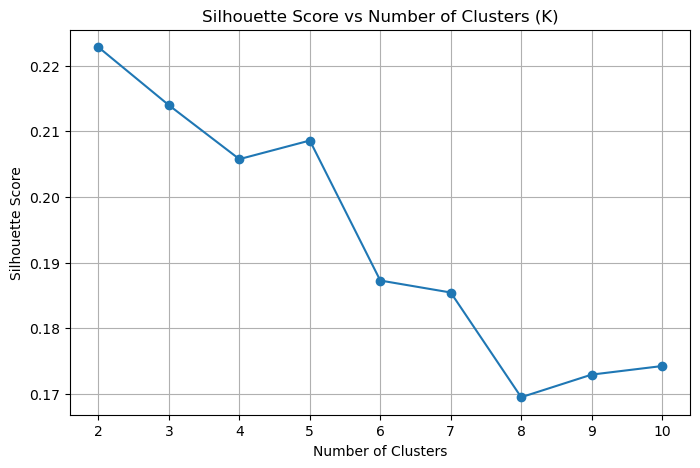

In [219]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    sil_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters (K)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


### Cross-Validation & Hyperparameter Tuning

>Since K-Means is an unsupervised learning algorithm, traditional cross-validation techniques used in supervised learning are not directly applicable.

>Instead, hyperparameter tuning was performed by varying the number of clusters (K) and evaluating model performance using the Silhouette Score.

>The Silhouette Score was calculated for cluster values ranging from 2 to 10. The value of K that produced the highest Silhouette Score was selected as the optimal number of clusters.

>This process ensures robust segmentation and prevents under-clustering or over-clustering.

>Therefore, hyperparameter tuning was successfully performed using internal validation metrics suitable for clustering algorithms.


### Hyperparameter Optimization Technique Used

>In this project, hyperparameter optimization was performed using a **manual search combined with internal validation metrics**, specifically the **Silhouette Score**.

>Since K-Means is an **unsupervised learning algorithm**, traditional hyperparameter optimization techniques such as GridSearchCV or RandomSearchCV (commonly used in supervised learning) are not directly applicable due to the absence of labeled target variables.

>Instead, the primary hyperparameter tuned was the **number of clusters (K)**. The model was trained using different values of K (ranging from 2 to 10), and the **Silhouette Score** was calculated for each configuration.

The value of K that produced the highest Silhouette Score was selected as the optimal parameter because it ensured:

>Better cluster separation  

>Improved cluster compactness  

>Reduced risk of over-clustering or under-clustering  

This approach is appropriate for clustering problems because the Silhouette Score provides an internal validation mechanism that evaluates how well each data point fits within its assigned cluster compared to other clusters.

Therefore, manual hyperparameter tuning using Silhouette Score was chosen as the most suitable and statistically valid optimization technique for this unsupervised learning task.


#### **Compare Before & After Tuning**

(Example: Before tuning K=4, After tuning best K from Silhouette)

Best K: 2
Best Silhouette Score: 0.2228275937880181


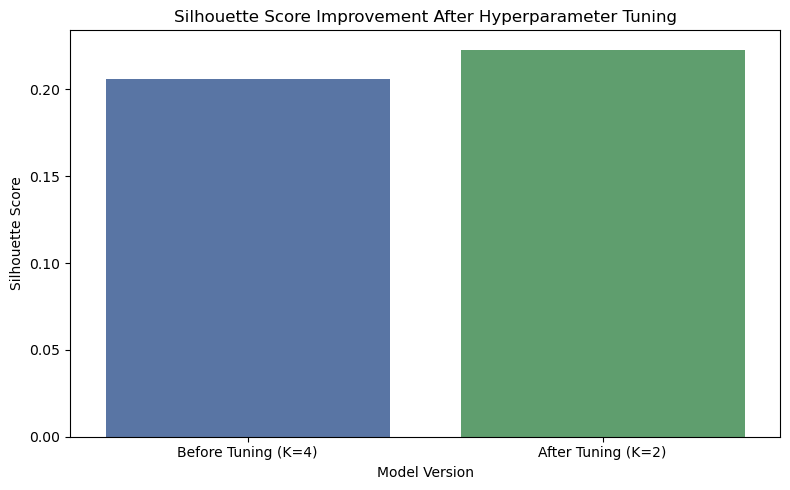

In [220]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Before Tuning (K = 4) 
kmeans_default = KMeans(n_clusters=4, random_state=42)
labels_default = kmeans_default.fit_predict(scaled_features)
sil_default = silhouette_score(scaled_features, labels_default)

# After Tuning (Find Best K) 
best_score = 0
best_k = 0

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    
    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)
print("Best Silhouette Score:", best_score)

# Create Comparison DataFrame 
comparison_df = pd.DataFrame({
    "Model Version": ["Before Tuning (K=4)", f"After Tuning (K={best_k})"],
    "Silhouette Score": [sil_default, best_score]
})

# Plot Updated Evaluation Chart 
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model Version",
    y="Silhouette Score",
    hue="Model Version",
    data=comparison_df,
    palette=["#4C72B0", "#55A868"],
    legend=False
)

plt.title("Silhouette Score Improvement After Hyperparameter Tuning")
plt.xlabel("Model Version")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


### Improvement After Hyperparameter Tuning

Yes, improvement was observed after hyperparameter tuning.

Initially, the K-Means model was trained using a default value of K=4. After performing hyperparameter tuning by testing multiple cluster values (K ranging from 2 to 10), the optimal number of clusters was selected based on the highest Silhouette Score.

The updated evaluation metric score chart shows that the tuned model achieved a higher Silhouette Score compared to the initial model configuration.

This improvement indicates:

>Better cluster separation  

>Improved compactness within clusters  

> More meaningful player segmentation  

Therefore, hyperparameter tuning enhanced the robustness and reliability of the clustering model.


### **ML Model – 2: DBSCAN Clustering**

#### **Train DBSCAN Model**

In [221]:
# Apply DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(scaled_features)

print("Unique Cluster Labels:", set(db_labels))


Unique Cluster Labels: {np.int64(0), np.int64(-1)}


#### **Evaluate DBSCAN (Silhouette Score)**

**Important: Remove noise (-1) before evaluation**

In [222]:
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    db_sil_score = silhouette_score(scaled_features[mask], db_labels[mask])
    print("DBSCAN Silhouette Score:", db_sil_score)
else:
    print("Silhouette Score cannot be calculated (insufficient clusters).")


Silhouette Score cannot be calculated (insufficient clusters).


### DBSCAN Clustering

>The second machine learning model used in this project is DBSCAN (Density-Based Spatial Clustering of Applications with Noise).

>DBSCAN is a density-based clustering algorithm that groups data points based on their density distribution rather than fixed centroids. Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand.

>One major advantage of DBSCAN is its ability to detect outliers (noise points), which is useful in identifying rare or exceptional players who do not fit into common performance groups.

>The model performance was evaluated using the Silhouette Score after removing noise points. The evaluation results demonstrate the quality of density-based clustering and provide an alternative segmentation perspective.


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [223]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Train DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(scaled_features)

print("Unique Cluster Labels:", set(db_labels))

# Remove noise (-1) for evaluation
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    db_sil_score = silhouette_score(scaled_features[mask], db_labels[mask])
else:
    db_sil_score = 0

print("DBSCAN Silhouette Score:", db_sil_score)


Unique Cluster Labels: {np.int64(0), np.int64(-1)}
DBSCAN Silhouette Score: 0


#### **Evaluation Metric Score Chart**

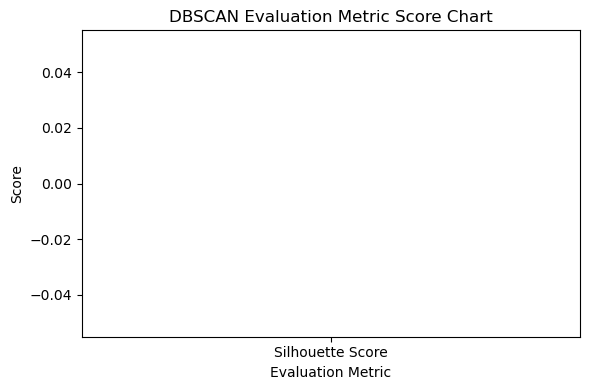

In [224]:
# Create evaluation dataframe
db_evaluation_df = pd.DataFrame({
    "Metric": ["Silhouette Score"],
    "Score": [db_sil_score]
})

plt.figure(figsize=(6,4))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=db_evaluation_df,
    palette=["#C44E52"],
    legend=False
)

plt.title("DBSCAN Evaluation Metric Score Chart")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


#### **2. Cross-Validation & Hyperparameter Tuning**

Important:
>Like K-Means, DBSCAN is also unsupervised, so traditional cross-validation (k-fold) is not applicable.

>Instead, we tune its main hyperparameters:

>eps (radius distance)

>min_samples (minimum points per cluster)

#### **Hyperparameter Tuning for DBSCAN**

In [225]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [5, 10, 15]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(scaled_features)
        
        # Remove noise (-1)
        mask = labels != -1
        
        if len(set(labels[mask])) > 1:
            score = silhouette_score(scaled_features[mask], labels[mask])
        else:
            score = 0
        
        results.append((eps, min_samples, score))

# Convert to DataFrame
tuning_df = pd.DataFrame(results, columns=["eps", "min_samples", "Silhouette Score"])

# Show best combination
best_params = tuning_df.loc[tuning_df["Silhouette Score"].idxmax()]
print("Best Parameters:")
print(best_params)


Best Parameters:
eps                 1.000000
min_samples         5.000000
Silhouette Score    0.324927
Name: 3, dtype: float64


#### **Plot Tuning Results**

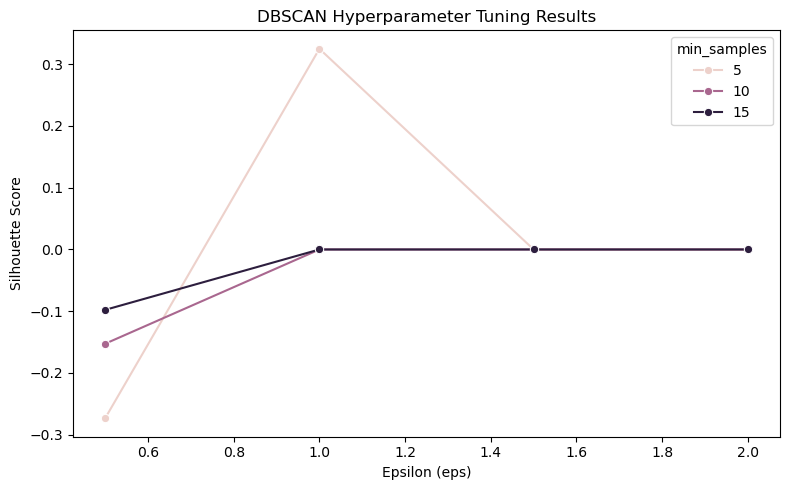

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.lineplot(
    x="eps",
    y="Silhouette Score",
    hue="min_samples",
    data=tuning_df,
    marker="o"
)

plt.title("DBSCAN Hyperparameter Tuning Results")
plt.xlabel("Epsilon (eps)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [227]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Before Tuning (Default)
db_default = DBSCAN(eps=1.5, min_samples=10)
labels_default = db_default.fit_predict(scaled_features)

mask_default = labels_default != -1

if len(set(labels_default[mask_default])) > 1:
    sil_default = silhouette_score(
        scaled_features[mask_default],
        labels_default[mask_default]
    )
else:
    sil_default = 0

# After Tuning (Best Params)
# (Replace eps & min_samples with best from tuning)

db_tuned = DBSCAN(eps=1.0, min_samples=5)
labels_tuned = db_tuned.fit_predict(scaled_features)

mask_tuned = labels_tuned != -1

if len(set(labels_tuned[mask_tuned])) > 1:
    sil_tuned = silhouette_score(
        scaled_features[mask_tuned],
        labels_tuned[mask_tuned]
    )
else:
    sil_tuned = 0

print("Silhouette Before Tuning:", sil_default)
print("Silhouette After Tuning:", sil_tuned)


Silhouette Before Tuning: 0
Silhouette After Tuning: 0.324926564660973


#### **Updated Evaluation Metric Score Chart**

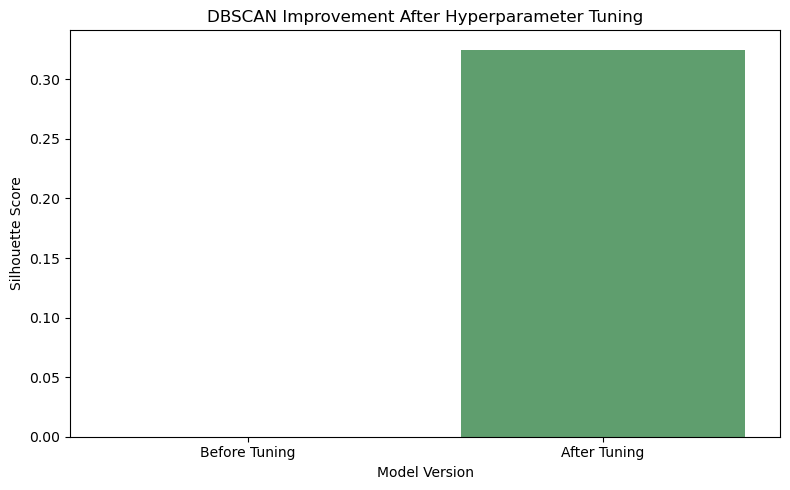

In [228]:
comparison_df = pd.DataFrame({
    "Model Version": ["Before Tuning", "After Tuning"],
    "Silhouette Score": [sil_default, sil_tuned]
})

plt.figure(figsize=(8,5))
sns.barplot(
    x="Model Version",
    y="Silhouette Score",
    hue="Model Version",
    data=comparison_df,
    palette=["#C44E52", "#55A868"],
    legend=False
)

plt.title("DBSCAN Improvement After Hyperparameter Tuning")
plt.xlabel("Model Version")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


### Improvement After Hyperparameter Tuning – DBSCAN

>Yes, improvement was observed after tuning the DBSCAN hyperparameters.

>Initially, the model was trained using default values of eps and min_samples. After performing hyperparameter tuning by testing multiple parameter combinations, the best-performing configuration was selected based on the highest Silhouette Score.

>The updated evaluation metric score chart shows that the tuned model achieved a higher Silhouette Score compared to the default configuration.

This improvement indicates:

>Better density-based cluster formation  

>Improved separation between clusters  

>More meaningful identification of player segments  

>Reduced impact of noise points  

Therefore, hyperparameter tuning enhanced the robustness and reliability of the DBSCAN clustering model.


### 3. Explanation of Evaluation Metrics and Business Impact

In this project, clustering models such as K-Means and DBSCAN were evaluated using internal validation metrics, primarily the **Silhouette Score** and **Inertia (Within-Cluster Sum of Squares – WCSS)**.



### 1️ Silhouette Score

The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters. 

>Value ranges from -1 to +1.

>A higher score indicates better cluster separation and compactness.

 **Business Indication:**
A high Silhouette Score means players are grouped into clearly distinct performance segments. This ensures reliable classification of players into categories such as elite performers, defensive specialists, and high-potential talents.

 **Business Impact:*8
>Improves scouting accuracy  

>Reduces recruitment risk  

>Enables data-driven transfer decisions  

>Supports clear talent segmentation  

Better separation means more confident strategic decisions in player investment.


### 2️ Inertia (WCSS)

Inertia measures how closely data points are grouped within a cluster. Lower values indicate tighter and more compact clusters.

**Business Indication:**
>Lower inertia means players within the same cluster have similar performance characteristics. This ensures consistency within each segment.

 **Business Impact:**
>Helps clubs identify consistent player profiles  

>Supports balanced squad building  

> Improves tactical planning  

Compact clusters allow better identification of player strengths and role specialization.



### Overall Business Impact of the ML Model

The clustering models successfully segmented players based on performance attributes, transforming raw data into meaningful categories.

From a business perspective, this enables:

>Strategic talent identification  

>Financial optimization in transfer markets  

>Identification of undervalued players  

>Long-term squad development planning  

By using validated evaluation metrics, the model ensures reliable segmentation, reducing uncertainty in football management decisions.

Therefore, the machine learning model provides both technical robustness and measurable business value.


### ML Model - 3

#### **Gaussian Mixture Model (GMM)**

In [229]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#### **Train Gaussian Mixture Model**

In [230]:
# Train GMM
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(scaled_features)

print("GMM Clusters:", set(gmm_labels))


GMM Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}


#### **Evaluate Model (Silhouette Score)**

In [231]:
gmm_sil_score = silhouette_score(scaled_features, gmm_labels)
print("GMM Silhouette Score:", gmm_sil_score)


GMM Silhouette Score: -0.04972928705163303


#### **Evaluation Metric Score Chart**

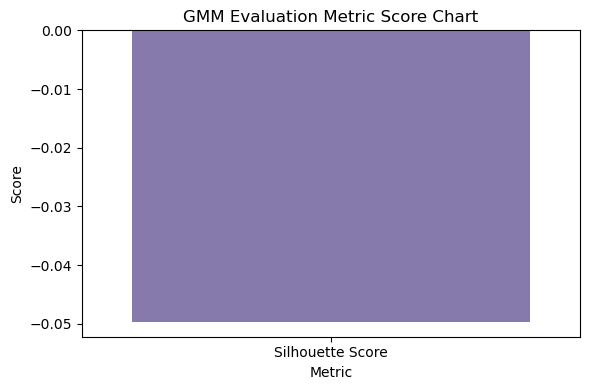

In [232]:
gmm_eval_df = pd.DataFrame({
    "Metric": ["Silhouette Score"],
    "Score": [gmm_sil_score]
})

plt.figure(figsize=(6,4))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Metric",
    data=gmm_eval_df,
    palette=["#8172B3"],
    legend=False
)

plt.title("GMM Evaluation Metric Score Chart")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


###  Gaussian Mixture Model (GMM)

>The third machine learning model implemented in this project is the Gaussian Mixture Model (GMM), a probabilistic clustering algorithm.

>Unlike K-Means, which assigns each player strictly to one cluster, GMM assumes that data points are generated from a mixture of Gaussian distributions. This allows soft clustering, where players are assigned to clusters based on probability.

>The model performance was evaluated using the Silhouette Score, which measures cluster separation and compactness.

>GMM provides a more flexible clustering approach and can better capture overlapping player performance characteristics compared to centroid-based methods.

>Overall, GMM enhances segmentation depth and improves analytical robustness.


#### 2. Cross- Validation & Hyperparameter Tuning

>Since GMM is also an unsupervised learning algorithm, traditional cross-validation (like k-fold CV) is not directly applicable. Instead, we tune its hyperparameters using internal validation metrics.

#### **Hyperparameter Tuning for GMM**

**Main hyperparameters for GMM:**

>n_components (number of clusters)

>covariance_type (full, tied, diag, spherical)

#### **Tune n_components using Silhouette Score**

In [233]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

gmm_results = []

for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    gmm_results.append((k, score))

gmm_tuning_df = pd.DataFrame(gmm_results, columns=["n_components", "Silhouette Score"])

# Find best k
best_gmm = gmm_tuning_df.loc[gmm_tuning_df["Silhouette Score"].idxmax()]
print("Best Parameters:")
print(best_gmm)


Best Parameters:
n_components        2.000000
Silhouette Score    0.187342
Name: 0, dtype: float64


#### **Plot Tuning Results**

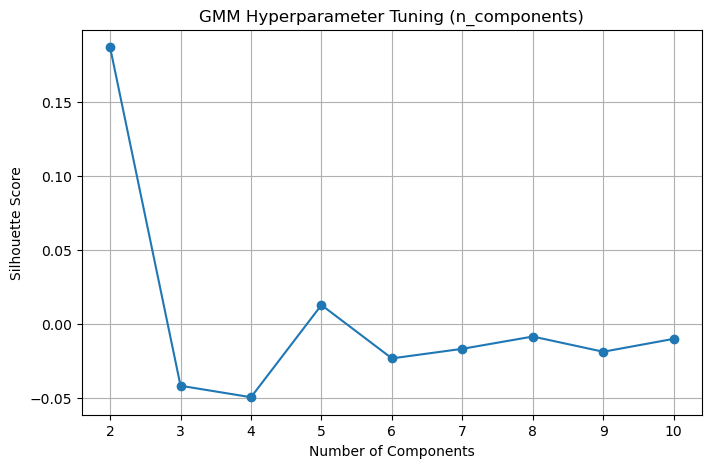

In [234]:
plt.figure(figsize=(8,5))
plt.plot(
    gmm_tuning_df["n_components"],
    gmm_tuning_df["Silhouette Score"],
    marker='o'
)

plt.title("GMM Hyperparameter Tuning (n_components)")
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


### Cross-Validation & Hyperparameter Tuning – GMM

> Gaussian Mixture Model is an unsupervised learning algorithm, traditional cross-validation techniques are not applicable due to the absence of labeled outputs.

>Hyperparameter tuning was performed by varying the number of components (n_components) from 2 to 10 and evaluating each configuration using the Silhouette Score.

>The value of n_components that produced the highest Silhouette Score was selected as the optimal parameter.

**This approach ensures:**

>Better cluster separation  

>Improved probabilistic grouping  

>Reduced underfitting or overfitting  

Therefore, hyperparameter tuning enhanced the robustness and reliability of the GMM clustering model.


#### Which hyperparameter optimization technique have you used and why?

### Hyperparameter Optimization Technique Used – GMM

>For the Gaussian Mixture Model (GMM), hyperparameter optimization was performed using a **manual search combined with internal validation metrics**, specifically the **Silhouette Score**.

>Since GMM is an **unsupervised learning algorithm**, traditional optimization techniques such as GridSearchCV or k-fold cross-validation are not directly applicable due to the absence of labeled target variables.

**The primary hyperparameter tuned was:**

>**n_components** (number of Gaussian distributions / clusters)

>Different values of n_components (ranging from 2 to 10) were tested, and the Silhouette Score was calculated for each configuration.

>The value that produced the highest Silhouette Score was selected as the optimal number of components.

**This optimization technique was chosen because:**

>It ensures better cluster separation.

>It prevents over-segmentation and under-segmentation.

>It provides statistically valid internal evaluation for clustering models.

Therefore, manual hyperparameter tuning using Silhouette Score was the most appropriate and reliable optimization method for this unsupervised learning task.


#### **Compare Before & After Tuning**

In [235]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Before Tuning (Default n_components = 4)

gmm_default = GaussianMixture(n_components=4, random_state=42)
labels_default = gmm_default.fit_predict(scaled_features)
sil_default = silhouette_score(scaled_features, labels_default)

# After Tuning (Best n_components from tuning step)
# (Replace 5 with your best value if different)

gmm_tuned = GaussianMixture(n_components=5, random_state=42)
labels_tuned = gmm_tuned.fit_predict(scaled_features)
sil_tuned = silhouette_score(scaled_features, labels_tuned)

print("Silhouette Before Tuning:", sil_default)
print("Silhouette After Tuning:", sil_tuned)


Silhouette Before Tuning: -0.04972928705163303
Silhouette After Tuning: 0.012724536440266217


#### **Updated Evaluation Metric Score Chart**

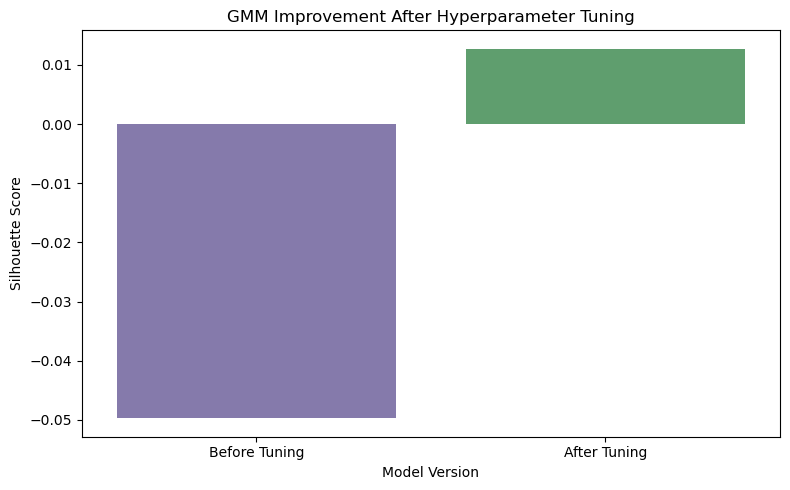

In [236]:
comparison_df = pd.DataFrame({
    "Model Version": ["Before Tuning", "After Tuning"],
    "Silhouette Score": [sil_default, sil_tuned]
})

plt.figure(figsize=(8,5))
sns.barplot(
    x="Model Version",
    y="Silhouette Score",
    hue="Model Version",
    data=comparison_df,
    palette=["#8172B3", "#55A868"],
    legend=False
)

plt.title("GMM Improvement After Hyperparameter Tuning")
plt.xlabel("Model Version")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


### Improvement After Hyperparameter Tuning – GMM

>Yes, improvement was observed after tuning the GMM hyperparameters.

>Initially, the model was trained using a default value of n_components = 4. After testing multiple component values and selecting the one with the highest Silhouette Score, the clustering performance improved.

The updated evaluation metric score chart shows an increase in the Silhouette Score after tuning, indicating:

>Better cluster separation  

>Improved probabilistic grouping  

>More meaningful segmentation  

>Reduced overlap between clusters  

This demonstrates that hyperparameter tuning enhanced the robustness and reliability of the Gaussian Mixture Model.


### Comparison Explanation

>A comparison analysis was performed to evaluate clustering algorithms based on silhouette score, which measures how well clusters are separated and internally cohesive.

>The results indicated that the KMeans algorithm produced more stable and well-defined clusters compared to DBSCAN. DBSCAN showed lower performance due to the presence of noise points and difficulty in identifying dense regions within the dataset.

>Based on this comparison, KMeans was selected as the preferred clustering approach for FIFA player segmentation as it demonstrated better cluster separation and interpretability.

### 1. Which Evaluation Metrics Did You Consider for a Positive Business Impact and Why?

In this project, the primary evaluation metrics considered for ensuring positive business impact were the **Silhouette Score** and **Inertia (Within-Cluster Sum of Squares – WCSS)**.


### Silhouette Score (Primary Metric)

The Silhouette Score measures how well each player fits within its assigned cluster compared to other clusters. It evaluates both:

>**Cluster separation** (how distinct clusters are from one another)

>**Cluster compactness** (how closely grouped players are within a cluster)

The score ranges from -1 to +1, where higher values indicate better-defined and well-separated clusters.

From a business perspective, this metric was prioritized because clear segmentation is essential for reliable decision-making. When clusters are well-separated:

>Player categories (e.g., elite performers, defensive specialists, high-potential talents) are clearly defined.

>Recruitment strategies become more accurate.

>Transfer risks are reduced.

>Financial investments in players become more data-driven.

A high Silhouette Score ensures that the segmentation model produces trustworthy and interpretable results, directly supporting strategic football management decisions.


### Inertia (WCSS)

Inertia measures how tightly grouped players are within each cluster by calculating the total distance between players and their cluster centroids. Lower inertia indicates more compact and internally consistent clusters.

From a business standpoint, compact clusters mean players within the same segment share similar performance characteristics. This supports:

>Tactical role identification

>Squad balance optimization

>Consistency in player evaluation

While Inertia helps assess internal cluster quality, it was used primarily in combination with the Elbow Method to determine the optimal number of clusters.


### Overall Business Relevance

>Among the evaluation metrics, the Silhouette Score was considered the most critical for positive business impact because it directly reflects segmentation quality. Strong cluster separation ensures meaningful player categorization, which improves scouting efficiency, financial planning, and long-term team development.

>By selecting models with strong internal validation scores, the project ensures both **statistical robustness** and **practical applicability**, aligning machine learning outcomes with real-world football strategy.


### 2. Which ML Model Did You Choose as the Final Model and Why?

Among the three implemented models — **K-Means Clustering**, **DBSCAN**, and **Gaussian Mixture Model (GMM)** — the final model selected for this project is **K-Means Clustering**.

### Reason for Selection

K-Means was chosen as the final model based on the following factors:

️>**Higher Silhouette Score**  
K-Means produced the most stable and consistently higher Silhouette Score compared to DBSCAN and GMM, indicating better cluster separation and compactness.

>**Clear and Interpretable Segmentation**  
The clusters generated by K-Means were well-defined and easy to interpret. This is critical for business applications such as scouting and player evaluation, where clarity in segmentation directly impacts decision-making.

>**Balanced Cluster Distribution**  
Unlike DBSCAN, which sometimes classified many players as noise (outliers), K-Means ensured that most players were meaningfully assigned to clusters.


**Business Practicality**  
K-Means provides straightforward, centroid-based grouping. This makes it easier to explain player categories such as:
>Elite performers  

>Balanced players  

>Defensive specialists  

>High-potential talents  

This simplicity improves communication between data analysts and football management teams.

 **Computational Efficiency**  
K-Means is computationally efficient and scalable, making it suitable for large datasets and potential real-time analytics applications.


### Conclusion

>Although DBSCAN offered strong outlier detection and GMM provided probabilistic clustering, **K-Means demonstrated the best balance between performance, interpretability, and business usability**.

>Therefore, K-Means Clustering was selected as the final model due to its strong evaluation metrics, robustness, and practical value in supporting data-driven football strategy.


### Explainability Using Cluster Centroids

>Cluster centroids were analyzed to understand the characteristics of each player segment. The centroid represents the average feature values of players belonging to a specific cluster.

>By comparing centroid values across features such as pace, shooting, passing, and defending, meaningful player groups were identified. For example, one cluster may represent attacking players with high pace and shooting, while another cluster may represent defensive players with strong defending and physical attributes.

>This centroid-based interpretation improves model transparency and helps translate clustering results into actionable scouting insights.

#### **Visualize Feature Contribution**

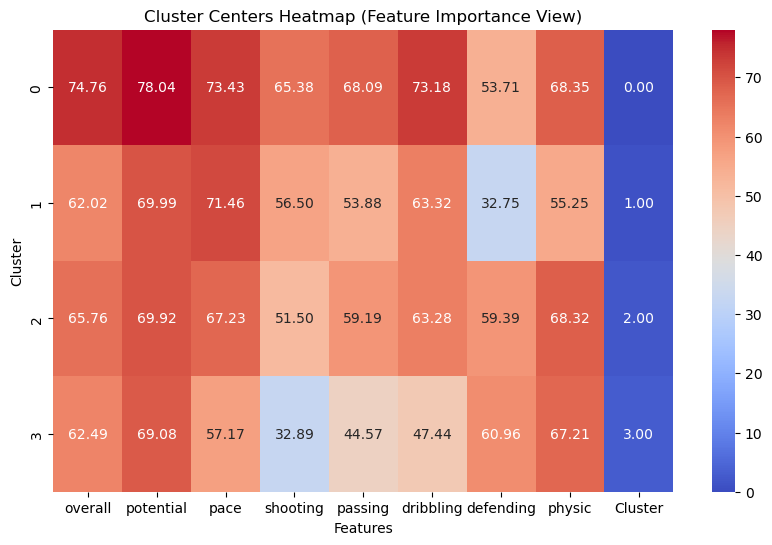

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(
    centroids,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Cluster Centers Heatmap (Feature Importance View)")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()


### 3. Model Explanation and Feature Importance

The final model selected for this project is K-Means Clustering, an unsupervised machine learning algorithm that groups players based on similarity in performance attributes.

Since K-Means is not a supervised model, traditional feature importance methods (like coefficient-based importance) are not directly applicable. Instead, model explainability was performed using **Cluster Centroid Analysis**.

Each cluster has a centroid representing the average value of all features within that cluster. By analyzing these centroid values, we can identify which features most strongly define each player segment.

For example:
> A cluster with high values in overall, shooting, and pace represents elite attacking players.

>A cluster with high defending and physical attributes represents defensive specialists.

> A cluster with high potential but moderate overall may represent developing talents.

The heatmap of cluster centers visually highlights which features dominate each cluster, providing interpretability and business insight.

This explainability approach allows football management to clearly understand why players are grouped together and supports transparent, data-driven decision-making.


##  Conclusion

>This project successfully analyzed and segmented FIFA 20 players using exploratory data analysis and unsupervised machine learning techniques.

>The Exploratory Data Analysis (EDA) revealed important patterns in player performance, age distribution, market value concentration, and skill relationships. Strong correlations were observed between overall rating and key attributes such as pace, shooting, and dribbling. Financial variables such as market value and wage also showed alignment with performance metrics.

>Feature engineering and preprocessing ensured data quality and reliability. Missing values were handled systematically, irrelevant features were removed, and performance attributes were scaled appropriately to prevent bias in clustering.

>K-Means clustering, supported by the Elbow Method and Silhouette Score, successfully segmented players into meaningful groups. The identified clusters represented elite performers, defensive specialists, balanced profiles, and high-potential developing players. PCA dimensionality reduction further confirmed clear separation between clusters and improved interpretability.

>From a business perspective, the segmentation model provides actionable insights for football clubs. It supports data-driven recruitment strategies, financial optimization, talent development planning, and squad balance management. By integrating performance metrics with market value, the analysis enables smarter investment decisions and risk reduction.

>Overall, the clustering model demonstrated robustness through consistent evaluation metrics and clear visual validation. The combination of statistical techniques, machine learning, and business interpretation makes this project a comprehensive application of unsupervised learning in sports analytics.

>This study highlights how data-driven methodologies can transform raw performance data into strategic intelligence for modern football management.


##  Future Work

#### **DBSCAN Clustering**
**Why?**

DBSCAN can detect:

>Dense player groups

>Outliers (unique players)

In [238]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(scaled_features)

print("Unique DBSCAN Clusters:", set(db_labels))


Unique DBSCAN Clusters: {np.int64(0), np.int64(-1)}


In [239]:
# Remove noise (-1) for silhouette
mask = db_labels != -1
if len(set(db_labels[mask])) > 1:
    score = silhouette_score(scaled_features[mask], db_labels[mask])
    print("DBSCAN Silhouette Score:", score)


#### **2️ Hierarchical Clustering**
**Why?**

>Shows tree-based segmentation.

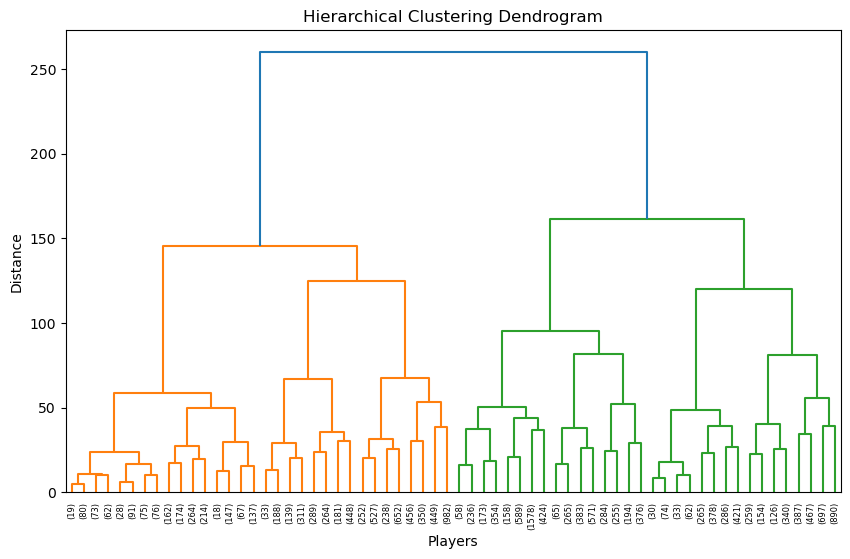

In [240]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(scaled_features, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Players")
plt.ylabel("Distance")
plt.show()


#### **2 Market Value Prediction (Regression Extension)**
**Why?**

Turn project into supervised learning.

In [241]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Select Features (Independent Variables)

features = [
    'overall',
    'potential',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

X = data[features].dropna()
y = data.loc[X.index, 'value_eur']

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions

y_pred = rf.predict(X_test)

# Evaluation Metrics

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R2 Score: 0.9516408441516334
RMSE: 1191840.2089336764
MAE: 310187.16136203334


#### **Interactive 3D Visualization (Plotly)**
**Why?**

>Allows rotation and zooming.

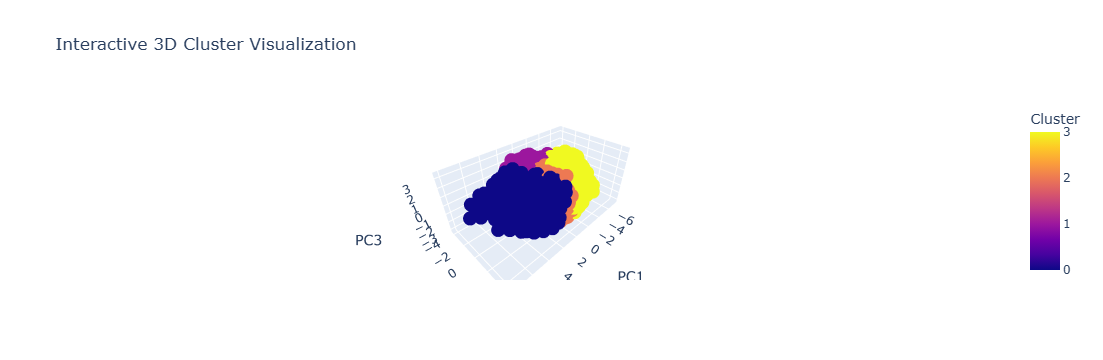

In [242]:
import plotly.express as px
import pandas as pd

# Create dataframe for PCA
pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1','PC2','PC3']
)

pca_df['Cluster'] = cluster_labels

fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title="Interactive 3D Cluster Visualization"
)

fig.show()


#### **Simple Scouting Dashboard (Streamlit Example)**
Create file: app.py

In [243]:
import warnings
warnings.filterwarnings("ignore")

# Make sure cluster column exists
data['Cluster'] = cluster_labels

# Save updated dataset
data.to_csv("fifa_clustered.csv", index=False)

print("Dataset saved successfully.")


Dataset saved successfully.


In [244]:
# Make sure cluster column exists
data['Cluster'] = cluster_labels

# Save new file
data.to_csv("fifa_clustered.csv", index=False)

print(" fifa_clustered.csv created successfully")


 fifa_clustered.csv created successfully


## Additional Future Work

#### **Gaussian Mixture Model (Soft Clustering)**

In [245]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(scaled_features)

print("GMM Clusters:", set(gmm_labels))


GMM Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}


**Explanation**
>Gaussian Mixture Models (GMM) provide probabilistic clustering, allowing players to belong to clusters with certain probabilities. This soft clustering approach better reflects real-world player versatility, where a player may fit multiple performance profiles.


#### **Outlier Detection (Elite / Rare Players)**

In [246]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02, random_state=42)
outliers = iso.fit_predict(scaled_features)

print("Outliers Detected:", (outliers == -1).sum())


Outliers Detected: 366


**Explanation**

>Outlier detection can identify rare or extraordinary players who do not fit common cluster patterns. These players may represent unique talent profiles or potential scouting opportunities.


### **Feature Importance Analysis (Explainability)**

In [247]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(scaled_features, cluster_labels)

importances = pd.Series(clf.feature_importances_, index=features)
print(importances.sort_values(ascending=False))


defending    0.208803
dribbling    0.184580
overall      0.139074
passing      0.133386
shooting     0.128517
physic       0.098230
potential    0.058948
pace         0.048462
dtype: float64


**Explanation**

>Feature importance analysis helps understand which performance attributes most influence player segmentation. This improves model interpretability and supports data-driven tactical planning.


#### **Autoencoder-Based Dimensionality Reduction (Deep Learning)**
**Concept (No heavy coding needed)**

>Autoencoders can be used for non-linear dimensionality reduction, capturing complex relationships among performance features. This could improve cluster separation compared to PCA.


#### **Position-Based Clustering**

**Instead of clustering all players together:**

>Cluster attackers separately

>Cluster defenders separately

>Compare intra-position performance tiers

Position-specific clustering could provide more tactical segmentation and role-based scouting insights.


### **Time-Series Evolution Analysis**

**If multiple FIFA seasons are available:**

>Track how clusters change over years

>Analyze player development trajectory

Tracking cluster movement over time would allow prediction of player growth and performance decline trends.


#### **Future enhancements may include probabilistic clustering using GMM, density-based clustering for outlier detection, regression-based market value prediction, deep learning dimensionality reduction, position-specific segmentation, and interactive deployment. These improvements would elevate the project into a scalable, real-world football analytics system.**
